# Chat

> High level chat api for fastllm similar to lisette

In [ ]:
#| default_exp chat

In [ ]:
#| hide
from cachy import enable_cachy,disable_cachy,doms

In [ ]:
#| hide
enable_cachy(hdrs=('content-type',))

In [ ]:
#| export
import asyncio, base64, json, mimetypes, random, string, ast, warnings
from typing import Optional,Callable
from html import escape
from toolslm.funccall import mk_ns, call_func, call_func_async, get_schema
from fastcore.utils import *
from fastcore.meta import delegates
from fastcore import imghdr
from fastcore.xml import Safe
from dataclasses import dataclass

from fastllm.types import *
from fastllm.acomplete import *

In [ ]:
#| hide
from fastcore.test import *
from fastllm.acomplete import api_registry, display_list, Usage
from IPython.display import Markdown, Image, Audio, Video
import httpx

We can see the currently registered fastllm apis below:

In [ ]:
api_registry.apis.keys()

dict_keys(['openai', 'openai_chat', 'anthropic', 'gemini'])

## fastllm

fastllm provides an convenient unified interface for most big LLM providers. Because it's so useful to be able to switch LLM providers with just one argument. We want to make it even easier to by adding some more convenience functions and classes. 

This is very similar to our other wrapper libraries for popular AI providers: [claudette](https://claudette.answer.ai/) (Anthropic), [gaspard](https://github.com/AnswerDotAI/gaspard) (Gemini), [cosette](https://answerdotai.github.io/cosette/) (OpenAI).

In [ ]:
ms = ["models/gemini-3-pro-preview", "models/gemini-3-flash-preview", "claude-sonnet-4-6", "gpt-4.1"]
msgs = [Msg(role='user', content=[Part(type=PartType.text, text='Hi there!', data={"cache_control": {"type": "ephemeral"}})])]
for m in ms:
    display(Markdown(f'**{m}:**'))
    display(await acomplete(msgs, m))

<div class="prose">

**models/gemini-3-pro-preview:**

</div>

<div class="prose">

Hello! How can I help you today?

<details>

- model: `models/gemini-3-pro-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=4, completion_tokens=9, total_tokens=217, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=204, raw={'promptTokenCount': 4, 'candidatesTokenCount': 9, 'totalTokenCount': 217, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 4}], 'thoughtsTokenCount': 204})`

</details>

</div>

<div class="prose">

**models/gemini-3-flash-preview:**

</div>

<div class="prose">

Hello! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=4, completion_tokens=9, total_tokens=163, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=150, raw={'promptTokenCount': 4, 'candidatesTokenCount': 9, 'totalTokenCount': 163, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 4}], 'thoughtsTokenCount': 150})`

</details>

</div>

<div class="prose">

**claude-sonnet-4-6:**

</div>

<div class="prose">

Hi there! 👋 How are you doing? Is there something I can help you with today?

<details>

- model: `claude-sonnet-4-6`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=10, completion_tokens=25, total_tokens=35, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 10, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 25, 'service_tier': 'standard', 'inference_geo': 'global'})`

</details>

</div>

<div class="prose">

**gpt-4.1:**

</div>

<div class="prose">

Hello! How can I help you today? 😊

<details>

- model: `gpt-4.1-2025-04-14`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=10, completion_tokens=11, total_tokens=21, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 10, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 11, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 21})`

</details>

</div>

In [ ]:
gpt54

'gpt-5.4'

In [ ]:
await acomplete(msgs, gpt54)

<div class="prose">

Hello! How can I help?

<details>

- model: `gpt-5.4-2026-03-05`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=9, completion_tokens=11, total_tokens=20, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 9, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 11, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 20})`

</details>

</div>

In [ ]:
await acomplete(msgs, gpt54m)

<div class="prose">

Hi there! How can I help you today?

<details>

- model: `gpt-5.4-mini-2026-03-17`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=9, completion_tokens=14, total_tokens=23, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 9, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 14, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 23})`

</details>

</div>

Custom modifications on model meta

In [ ]:
get_model_info('accounts/fireworks/models/kimi-k2p5', 'fireworks_ai')

<div class="prose">

```python
{ 'cache_read_input_token_cost': 1e-07,
  'input_cost_per_token': 6e-07,
  'litellm_provider': 'fireworks_ai',
  'max_input_tokens': 262144,
  'max_output_tokens': 262144,
  'max_tokens': 262144,
  'mode': 'chat',
  'output_cost_per_token': 3e-06,
  'source': 'https://fireworks.ai/pricing',
  'supports_function_calling': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_tool_choice': True,
  'supports_vision': True}
```

</div>

In [ ]:
get_model_info('accounts/fireworks/models/kimi-k2p6', 'fireworks_ai')

<div class="prose">

```python
{ 'cache_read_input_token_cost': 1e-07,
  'input_cost_per_token': 6e-07,
  'litellm_provider': 'fireworks_ai',
  'max_input_tokens': 262144,
  'max_output_tokens': 262144,
  'max_tokens': 262144,
  'mode': 'chat',
  'output_cost_per_token': 3e-06,
  'source': 'https://fireworks.ai/pricing',
  'supports_function_calling': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_tool_choice': True,
  'supports_vision': True}
```

</div>

In [ ]:
get_model_info('gpt-5.4', 'openai')

<div class="prose">

```python
{ 'cache_read_input_token_cost': 2.5e-07,
  'cache_read_input_token_cost_above_272k_tokens': 5e-07,
  'cache_read_input_token_cost_flex': 1.3e-07,
  'cache_read_input_token_cost_priority': 5e-07,
  'input_cost_per_token': 2.5e-06,
  'input_cost_per_token_above_272k_tokens': 5e-06,
  'input_cost_per_token_batches': 1.25e-06,
  'input_cost_per_token_flex': 1.25e-06,
  'input_cost_per_token_priority': 5e-06,
  'litellm_provider': 'openai',
  'max_input_tokens': 1050000,
  'max_output_tokens': 128000,
  'max_tokens': 128000,
  'output_cost_per_token': 1.5e-05,
  'output_cost_per_token_above_272k_tokens': 2.25e-05,
  'output_cost_per_token_batches': 7.5e-06,
  'output_cost_per_token_flex': 7.5e-06,
  'output_cost_per_token_priority': 3e-05,
  'supported_endpoints': ['/v1/chat/completions', '/v1/batch', '/v1/responses'],
  'supported_modalities': ['text', 'image'],
  'supported_output_modalities': ['text'],
  'supports_function_calling': True,
  'supports_minimal_reasoning_effort': True,
  'supports_native_streaming': True,
  'supports_none_reasoning_effort': True,
  'supports_parallel_function_calling': True,
  'supports_pdf_input': True,
  'supports_prompt_caching': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_service_tier': True,
  'supports_system_messages': True,
  'supports_tool_choice': True,
  'supports_vision': True,
  'supports_web_search': True,
  'supports_xhigh_reasoning_effort': True}
```

</div>

In [ ]:
get_model_info('gpt-5.4', 'codex')

<div class="prose">

```python
{ 'cache_creation_input_token_cost': 1.0000000000000001e-07,
  'cache_read_input_token_cost': 1.0000000000000001e-07,
  'cache_read_input_token_cost_above_272k_tokens': 5e-07,
  'cache_read_input_token_cost_flex': 1.3e-07,
  'cache_read_input_token_cost_priority': 5e-07,
  'input_cost_per_token': 1.0000000000000001e-07,
  'input_cost_per_token_above_272k_tokens': 5e-06,
  'input_cost_per_token_batches': 1.25e-06,
  'input_cost_per_token_flex': 1.25e-06,
  'input_cost_per_token_priority': 5e-06,
  'litellm_provider': 'openai',
  'max_input_tokens': 1050000,
  'max_output_tokens': 128000,
  'max_tokens': 128000,
  'output_cost_per_token': 5e-07,
  'output_cost_per_token_above_272k_tokens': 2.25e-05,
  'output_cost_per_token_batches': 7.5e-06,
  'output_cost_per_token_flex': 7.5e-06,
  'output_cost_per_token_priority': 3e-05,
  'supported_endpoints': ['/v1/chat/completions', '/v1/batch', '/v1/responses'],
  'supported_modalities': ['text', 'image'],
  'supported_output_modalities': ['text'],
  'supports_function_calling': True,
  'supports_minimal_reasoning_effort': True,
  'supports_native_streaming': True,
  'supports_none_reasoning_effort': True,
  'supports_parallel_function_calling': True,
  'supports_pdf_input': True,
  'supports_prompt_caching': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_service_tier': True,
  'supports_system_messages': True,
  'supports_tool_choice': True,
  'supports_vision': True,
  'supports_web_search': True,
  'supports_xhigh_reasoning_effort': True}
```

</div>

### Messages formatting

Let's start with making it easier to pass messages into litellm's `completion` function (including images, and pdf files).

In [ ]:
#| export
def _bytes2content(data):
    "Convert bytes to litellm content dict (image, pdf, audio, video)"
    mtype = detect_mime(data)
    if not mtype: raise ValueError(f'Data must be a supported file type, got {data[:10]}')
    encoded = base64.b64encode(data).decode("utf-8")    
    if mtype.startswith('image/'): return Part(type=PartType.input_image, text=f'data:{mtype};base64,{encoded}')
    return Part(type=PartType.input_file, text=f'data:{mtype};base64,{encoded}')


Cache control is added to `Part.data`, it can be added to `tool_use`, `tool_result`, `user`, `asssitant` blocks:

In [ ]:
#| export
def _add_cache_control(msg,          # LiteLLM formatted msg
                       ttl=None):    # Cache TTL: '5m' (default) or '1h'
    "cache `msg` with default time-to-live (ttl) of 5minutes ('5m'), but can be set to '1h'."
    cc = {"type": "ephemeral"} | ({"ttl": ttl} if ttl else {})
    cache_idx = None
    for idx, part in enumerate(msg.content):
        if part.type in (PartType.text, PartType.tool_use): cache_idx = idx
    msg.content[idx].data = merge(msg.content[idx].data or {}, dict(cache_control=cc))
    return msg

def _has_cache(msg):
    "Check if msg has cache_control set"
    return any(part.data and 'cache_control' in part.data for part in msg.content)

def remove_cache_ckpts(msg):
    "remove cache checkpoints and return msg."
    for part in msg.content:
        if part.data: part.data.pop('cache_control', None)
    return msg

def _mk_content(o):
    if isinstance(o, str): return Part(type=PartType.text, text=o.strip())
    elif isinstance(o,bytes): return _bytes2content(o)
    return o

def contents(c):
    "Get Msg object from Completion."
    if not c.message: return ''
    return c.message

def stop_reason(c):
    if not c.finish_reason: return 'unk'
    return c.finish_reason

Test with regular content message:

In [ ]:
msg_content = Msg(role='user', content=[_mk_content('hello')])
_add_cache_control(msg_content)
test_eq(msg_content.content[-1].data.get('cache_control'), {'type': 'ephemeral'})
test_eq(_has_cache(msg_content), True)
remove_cache_ckpts(msg_content)
test_eq(_has_cache(msg_content), False)

Test with assistant message with tool_calls:

In [ ]:
parts = [Part(type=PartType.text, text="I'll calculate both additions for you using the simple_add tool in parallel.", data={'type': 'text', 'text': "I'll calculate both additions for you using the simple_add tool in parallel."}),
        Part(type=PartType.tool_use, text=None, data={'id': 'toolu_01LyH4DdFWEbU9G7cg2XarVf', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False, 'caller': {'type': 'direct'}}),
        Part(type=PartType.tool_use, text=None, data={'id': 'toolu_01JrpzizGDyz3BP2Ec2j1Ye1', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 20}, 'server': False, 'caller': {'type': 'direct'}})]
msg_tool = Msg(role='assistant', content=parts)

In [ ]:
_add_cache_control(msg_tool)
test_eq(msg_tool.content[-1].data.get('cache_control'), {'type': 'ephemeral'})
test_eq(msg_tool.content[0].data.get('cache_control'), None)  # no cache in text
test_eq(_has_cache(msg_tool), True)
remove_cache_ckpts(msg_tool)
test_eq(_has_cache(msg_tool), False)

In [ ]:
#| export
def mk_msg(
    content,      # Content: str, bytes (image), list of mixed content, or dict w 'role' and 'content' fields
    role="user",  # Message role if content isn't already a dict/Message
    cache=False,  # Enable Anthropic caching
    ttl=None      # Cache TTL: '5m' (default) or '1h'
):
    "Create a LiteLLM compatible message."
    if content is None: return None
    if isinstance(content, Msg): return content
    if isinstance(content, Completion): return content.message
    if isinstance(content, list) and len(content) == 1 and isinstance(content[0], str): parts = [Part(PartType.text, content[0])]
    elif isinstance(content, list): parts = [_mk_content(o) for o in content]
    elif isinstance(content, dict): return Msg(role=content['role'], content=[Part(PartType.text, content['content'])])
    else: parts = [Part(PartType.text, content)]
    msg = Msg(role=role, content=parts)
    return _add_cache_control(msg, ttl=ttl) if cache else msg

Now we can use mk_msg to create different types of messages.

Simple text:

In [ ]:
msg = mk_msg("hey")
msg

<div class="prose">

**Msg**

- role: `user`

<contents>

**Part** (`text`)

hey

<details>

- data: `None`

</details>

</contents>

</div>

Which can be passed to fastllm's `acomplete` function like this:

In [ ]:
model = ms[1] # use 2.5-pro, 3-pro is very slow even to run tests as of making

In [ ]:
res = await acomplete([msg], model)
res

<div class="prose">

Hey there! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=2, completion_tokens=10, total_tokens=37, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=25, raw={'promptTokenCount': 2, 'candidatesTokenCount': 10, 'totalTokenCount': 37, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 2}], 'thoughtsTokenCount': 25})`

</details>

</div>

We'll add a little shortcut to make examples and testing easier here:

In [ ]:
async def c(msgs, m=model, **kw):
    msgs = [msgs] if isinstance(msgs,Msg) else listify(msgs)
    return await acomplete(msgs, m, **kw)

In [ ]:
await c(msg)

<div class="prose">

Hey there! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=2, completion_tokens=10, total_tokens=37, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=25, raw={'promptTokenCount': 2, 'candidatesTokenCount': 10, 'totalTokenCount': 37, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 2}], 'thoughtsTokenCount': 25})`

</details>

</div>

Lists w just one string element are flattened for conciseness:

In [ ]:
test_eq(mk_msg("hey"), mk_msg(["hey"]))

Text and images:

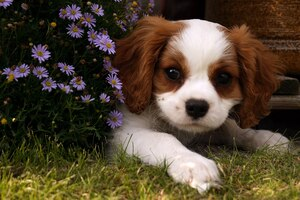

In [ ]:
img_fn = Path('samples/puppy.jpg')
Image(filename=img_fn, width=200)

In [ ]:
msg = mk_msg(['hey what in this image?',img_fn.read_bytes()])
str(msg)[:300]

"Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='hey what in this image?', data=None), Part(type=<PartType.input_image: 'input_image'>, text='data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/4gxUSUNDX1BST0ZJTEUAAQEAAAxEVUNDTQJAAABtbnRyUkdCIFhZWiAH0wAEAAQAAAAAAABhY3NwTVNGVAAAAABDQ"

In [ ]:
await c(msg)

<div class="prose">

The image shows an adorable **Cavalier King Charles Spaniel puppy**.

Here are the details:

*   **The Puppy:** It has classic "Blenheim" coloring—a pearly white coat with chestnut-brown patches over its long, floppy ears and around its large, dark eyes. It is lying down, looking directly at the camera with its front paws stretched forward.
*   **Flowers:** To the left of the puppy is a dense cluster of small, daisy-like purple flowers with yellow centers (likely asters).
*   **Environment:** The puppy is resting on green grass. The background behind the puppy is dark and out of focus, featuring what looks like a wooden structure or a large flower pot.

The overall scene is very sweet and focused on the puppy's expressive face.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=1087, completion_tokens=167, total_tokens=1873, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=619, raw={'promptTokenCount': 1087, 'candidatesTokenCount': 167, 'totalTokenCount': 1873, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 7}, {'modality': 'IMAGE', 'tokenCount': 1080}], 'thoughtsTokenCount': 619})`

</details>

</div>

In [ ]:
await c(msg, 'accounts/fireworks/models/kimi-k2p6', vendor_name='fireworks_ai')

<div class="prose">

<details><summary>Thinking</summary>

The user wants me to identify what's in the image. Looking at the image, I can see a small puppy with brown and white fur lying on green grass. Next to the puppy are some purple flowers (likely asters or similar small purple flowers). The puppy appears to be a Cavalier King Charles Spaniel puppy, given its distinctive coloring - white face with brown ears and markings, large dark eyes, and that specific puppy-like appearance. It's lying down with its front paws extended on the grass.

I should describe the image clearly and accurately. The image shows:
- A puppy (Cavalier King Charles Spaniel)
- Brown and white coloring
- Lying on green grass
- Purple flowers nearby (to the left of the puppy)
- Cute, looking at camera

Let me provide a friendly, descriptive answer.

</details>

This image shows an adorable **Cavalier King Charles Spaniel puppy** lying on green grass. The puppy has the breed's characteristic **brown and white coat**, with large dark eyes, floppy brown ears, and a white blaze down the center of its face. It's resting with its front paws stretched out, looking directly at the camera. 

Next to the puppy (on the left side of the image) is a cluster of **small purple flowers**—likely asters or daisy-like blooms—growing in the grass. The overall scene is very cute and gives off a sweet, summery, outdoor vibe! 🐶🌸

<details>

- model: `accounts/fireworks/models/kimi-k2p6`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=107, completion_tokens=300, total_tokens=407, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'prompt_tokens': 107, 'total_tokens': 407, 'completion_tokens': 300, 'prompt_tokens_details': {'cached_tokens': 0}})`

</details>

</div>

Let's also demonstrate this for PDFs

In [ ]:
pdf_fn = Path('samples/solveit.pdf')
msg = mk_msg(['Who is the author of this pdf?', pdf_fn.read_bytes()])
await c(msg)

<div class="prose">

Based on the text in the document, the author is **Jeremy Howard**, co-founder of **fast.ai**.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=541, completion_tokens=24, total_tokens=769, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=204, raw={'promptTokenCount': 541, 'candidatesTokenCount': 24, 'totalTokenCount': 769, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 9}, {'modality': 'IMAGE', 'tokenCount': 532}], 'thoughtsTokenCount': 204})`

</details>

</div>

Some models like Gemini support audio and video:

In [ ]:
wav_data = httpx.get("https://openaiassets.blob.core.windows.net/$web/API/docs/audio/alloy.wav").content
# Audio(wav_data)  # uncomment to preview

In [ ]:
msg = mk_msg(['What is this audio saying?', wav_data])
await c([msg], ms[1])

<div class="prose">

This audio is saying: "The sun rises in the east and sets in the west. This simple fact has been observed by humans for thousands of years."

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=181, completion_tokens=31, total_tokens=347, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=135, raw={'promptTokenCount': 181, 'candidatesTokenCount': 31, 'totalTokenCount': 347, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 7}, {'modality': 'AUDIO', 'tokenCount': 174}], 'thoughtsTokenCount': 135})`

</details>

</div>

In [ ]:
vid_data = httpx.get("https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/pixel8.mp4").content

In [ ]:
msg = mk_msg(['Concisely, what is happening in this video?', vid_data])
await c([msg], ms[1])

<div class="prose">

A photographer named Saeka Shimada takes a walk through Tokyo at night, using the Google Pixel 8 Pro's "Video Boost" and "Night Sight" features to capture vibrant and detailed video in low-light settings.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=5205, completion_tokens=46, total_tokens=5471, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=220, raw={'promptTokenCount': 5205, 'candidatesTokenCount': 46, 'totalTokenCount': 5471, 'promptTokensDetails': [{'modality': 'VIDEO', 'tokenCount': 5193}, {'modality': 'TEXT', 'tokenCount': 12}], 'thoughtsTokenCount': 220})`

</details>

</div>

### Caching

Some providers such as Anthropic require manually opting into caching. Uncomment to run the following tests:

In [ ]:
# def cpr(i): return f'{i} '*1024 + 'This is a caching test. Report back only what number you see repeated above.'

In [ ]:
# #| eval: false
# disable_cachy()

In [ ]:
# msg = mk_msg(cpr(1), cache=True)
# res = await c(msg, ms[2])
# res

Anthropic has a maximum of 4 cache checkpoints, so we remove previous ones as we go:

In [ ]:
# print(res)

In [ ]:
# mk_msg(res)

In [ ]:
# res = await c([remove_cache_ckpts(msg), mk_msg(res), mk_msg(cpr(2), cache=True)], ms[2])
# res

We see that the first message was cached, and this extra message has been written to cache:

In [ ]:
# res.usage.raw

We can add a bunch of large messages in a loop to see how the number of cached tokens used grows.

We do this for 25 times to ensure it still works for more than >20 content blocks, [which is a known anthropic issue](https://docs.claude.com/en/docs/build-with-claude/prompt-caching).

The code below is commented by default, because it's slow. Please uncomment when working on caching.

In [ ]:
# h = []
# msg = mk_msg(cpr(1), cache=True)
# 
# for o in range(2,25):
#     h += [remove_cache_ckpts(msg), mk_msg(res)]
#     msg = mk_msg(cpr(o), cache=True)
#     res = c(h+[msg])
#     detls = res.usage.prompt_tokens_details
#     print(o, detls.cached_tokens, detls.cache_creation_tokens, end='; ')

In [ ]:
# #| hide
# enable_cachy(hdrs=('content-type',))

### Reconstructing formatted outputs

Lisette can call multiple tools in a loop. Further down this notebook, we'll provide convenience functions for formatting such a sequence of toolcalls and responses into one formatted output string.

For now, we'll show an example and show how to transform such a formatted output string back into a valid ~~LiteLLM~~ fastllm history.

```
tool_res_part = Part(type=PartType.tool_result, text='The answer is 42. ' * 200, data={**cc, 'id': 'toolu_test', 'name': 'compute'})
```

In [ ]:
fmt_outp = '''
I'll solve this step-by-step, using parallel calls where possible.

<details class='tool-usage-details'>

```json
{
  "id": "toolu_01KjnQH2Nsz2viQ7XYpLW3Ta",
  "call": { "function": "simple_add", "arguments": { "a": 10, "b": 5 } },
  "result": "15",
  "server": false
}
```

</details>

<details class='tool-usage-details'>

```json
{
  "id": "toolu_01Koi2EZrGZsBbnQ13wuuvzY",
  "call": { "function": "simple_add", "arguments": { "a": 2, "b": 1 } },
  "result": "3",
  "server": false
}
```

</details>

Now I need to multiply 15 * 3 before I can do the final division:

<details class='tool-usage-details'>

```json
{
  "id": "toolu_0141NRaWUjmGtwxZjWkyiq6C",
  "call": { "function": "multiply", "arguments": { "a": 15, "b": 3 } },
  "result": "45",
  "server": false
}
```

</details>

<details class='token-usage-details'><summary>Cache hit: 81.8% | Tokens: total=23,276 input=23,158 (+18,910 cached, 0 new) output=118 (reasoning 23)</summary>

`Usage(prompt_tokens=3, completion_tokens=10, total_tokens=13, raw={'input_tokens': 3, 'cache_creation_input_tokens': 2079, 'cache_read_input_tokens': 2070, 'cache_creation': {'ephemeral_5m_input_tokens': 2079, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 10, 'service_tier': 'standard', 'inference_geo': 'global'})`

</details>
'''

In [ ]:
#| export
tool_dtls_tag = "<details class='tool-usage-details'>"
re_tools = re.compile(fr"^({tool_dtls_tag}\n*(?:<summary>(?P<summary>.*?)</summary>\n*)?\n*```json\n+(.*?)\n+```\n+</details>)",
                      flags=re.DOTALL|re.MULTILINE)
token_dtls_tag = "<details class='token-usage-details'>"
re_token = re.compile(fr"^{re.escape(token_dtls_tag)}<summary>.*?</summary>\n*\n*`.*?`\n*\n*</details>\n?",
                      flags=re.DOTALL|re.MULTILINE)

We can split into chunks of (text,toolstr,json):

In [ ]:
sp = re_tools.split(fmt_outp)
for o in list(chunked(sp, 3, pad=True)): print('- ', o)

-  ["\nI'll solve this step-by-step, using parallel calls where possible.\n\n", '<details class=\'tool-usage-details\'>\n\n```json\n{\n  "id": "toolu_01KjnQH2Nsz2viQ7XYpLW3Ta",\n  "call": { "function": "simple_add", "arguments": { "a": 10, "b": 5 } },\n  "result": "15",\n  "server": false\n}\n```\n\n</details>', None]
-  ['{\n  "id": "toolu_01KjnQH2Nsz2viQ7XYpLW3Ta",\n  "call": { "function": "simple_add", "arguments": { "a": 10, "b": 5 } },\n  "result": "15",\n  "server": false\n}', '\n\n', '<details class=\'tool-usage-details\'>\n\n```json\n{\n  "id": "toolu_01Koi2EZrGZsBbnQ13wuuvzY",\n  "call": { "function": "simple_add", "arguments": { "a": 2, "b": 1 } },\n  "result": "3",\n  "server": false\n}\n```\n\n</details>']
-  [None, '{\n  "id": "toolu_01Koi2EZrGZsBbnQ13wuuvzY",\n  "call": { "function": "simple_add", "arguments": { "a": 2, "b": 1 } },\n  "result": "3",\n  "server": false\n}', '\n\nNow I need to multiply 15 * 3 before I can do the final division:\n\n']
-  ['<details class=\'t

```py
tool_use_msg = Msg(role='assistant', content=[Part(type=PartType.tool_use, data={'id': 'toolu_test', 'name': 'compute', 'arguments': {}, 'server': False})])
tool_res_msg = Msg(role='tool', content=[Part(type=PartType.tool_result, text='The answer is 42. ' * 200, data={**cc, 'id': 'toolu_test', 'name': 'compute'})])
```

#### Handling fenced calls

In [ ]:
#| export
_fence_back = '`````'
_fence_re = re.compile(f'^{_fence_back}(py|bash)\n(.*?)\n{_fence_back}', re.DOTALL | re.MULTILINE)
_result_re = re.compile(f'\n{_fence_back}result\n(.*?)\n{_fence_back}\n', re.DOTALL)
_lang2tool = dict(py='python', bash='bash')

class FenceToolStop:
    def __init__(self, langs): self.langs = langs
    def __call__(self, text):
        "Return trim result if complete fence detected in active lang"
        m = _fence_re.search(text)
        if m and m.group(1) in self.langs: return m.group(0)

In [ ]:
# _fence_re matches py/bash fences
test_eq(bool(_fence_re.search('\n`````py\nprint(1)\n`````\n')), True)
test_eq(bool(_fence_re.search('\n`````bash\nls\n`````\n')), True)
# Doesn't match incomplete fences
test_eq(bool(_fence_re.search('\n`````py\nprint(1)')), False)
# Doesn't match 3 backticks
test_eq(bool(_fence_re.search('\n```py\nprint(1)\n```\n')), False)
# Doesn't match inside a line
test_eq(bool(_fence_re.search('some text `````py\nprint(1)\n`````\n')), False)
# Doesn't match python or sh
test_eq(bool(_fence_re.search('\n`````python\nprint(1)\n`````\n')), False)
test_eq(bool(_fence_re.search('\n`````sh\nls\n`````\n')), False)

# _result_re matches result fences
m = _result_re.search('\n`````result\nhello world\n`````\n')
test_eq(m.group(1), 'hello world')

In [ ]:
#| export
def extract_fence_call(text):
    "Return (lang, code) if text ends with terminated py/bash fence, else None"
    ms = list(_fence_re.finditer(text))
    if not ms: return None
    m = ms[-1]
    if not text[m.end():].strip(): return m.group(1), m.group(2)

In [ ]:
# Ends with py fence
test_eq(extract_fence_call('\n`````py\nprint(1)\n`````\n'), ('py', 'print(1)'))
# Ends with bash fence
test_eq(extract_fence_call('prose\n`````bash\nls -la\n`````\n'), ('bash', 'ls -la'))
# Fence mid-text → None
test_eq(extract_fence_call('\n`````py\nprint(1)\n`````\nmore text'), None)
# No fence → None
test_eq(extract_fence_call('hello world'), None)
# Pipe chars in code
test_eq(extract_fence_call('\n`````py\nx = 1 | 2\n`````\n'), ('py', 'x = 1 | 2'))

In [ ]:
#| export
@patch(as_prop=True)
def text(self:Msg): return ''.join(p.text or '' for p in self.content if p.type == PartType.text)

Code fence tool is a stop condition which will trigger another round of toolloop, and we'll get a new msg back in hist. That means each `msg` can only have at most 1 code fence tool call

In [ ]:
#| export
def _mk_result_fence(output): return f"\n{_fence_back}result\n{output}\n{_fence_back}\n"

def _split_msg_on_fences(msg):
    "Split an assistant Msg on result fences, return list of Msgs"
    if msg.role != 'assistant': return [msg]
    if not _result_re.search(msg.text): return [msg]
    res, asst_parts, tool_parts = [], [], []
    for msg_part in msg.content:
        if msg_part.type == PartType.thinking: asst_parts.append(msg_part)
        elif msg_part.type == PartType.tool_use: tool_parts.append(msg_part)
        elif parts := _result_re.split(msg_part.text or ''):
            for i,p in enumerate(parts):
                if not p: continue
                if i % 2 == 0: res.append(Msg(role='assistant', content=asst_parts+[Part(type=PartType.text, text=p.strip())]))
                else:          res.append(Msg(role='user', content=[Part(type=PartType.text, text=_mk_result_fence(p))]))
    if tool_parts: res.append(Msg(role='assistant', content=tool_parts))
    return res

def _split_fence_msgs(msgs):
    "Split all assistant msgs on result fences for wire protocol"
    res = []
    for m in msgs: res.extend(_split_msg_on_fences(m))
    return res

In [ ]:
# No fence — unchanged
msg = Msg(role='assistant', content=[Part(PartType.text, 'Hello world')])
res = _split_msg_on_fences(msg)
test_eq(len(res), 1); test_eq(res[0].role, 'assistant')

# One result fence
msg = Msg(role='assistant', content=[Part(PartType.text, 'Let me calculate.\n`````py\n1+1\n`````\n\n`````result\n2\n`````\n\nDone.')])
res = _split_msg_on_fences(msg)
test_eq([m.role for m in res], ['assistant', 'user', 'assistant'])
test_eq('`````py\n1+1' in res[0].content[0].text, True)
test_eq('`````result\n2\n`````' in res[1].content[0].text, True)
test_eq('Done.' in res[2].content[0].text, True)

# Non-assistant — unchanged
msg = Msg(role='user', content=[Part(PartType.text, '`````result\n2\n`````')])
res = _split_msg_on_fences(msg)
test_eq([m.role for m in res], ['user'])

# Thinking first
msg = Msg(role='assistant', content=[
    Part(type=PartType.thinking, text='The user wants me to write an RNG function...', data={'citations': []}),
    Part(type=PartType.text, text='`````py\nimport random\n\ndef rng():\n    return random.random()\n\nprint(rng())\n`````\n`````result\n42\n`````\n', data={'citations': []})
])
res = _split_fence_msgs([msg])
test_eq([m.role for m in res], ['assistant', 'user'])
test_eq([p.type for p in res[0].content], ['thinking', 'text'])

# mixed code fence and tool call
msg = Msg(role='assistant', content=[
    Part(type=PartType.text, text='`````py\nimport random\n\ndef rng():\n    return random.random()\n\nprint(rng())\n`````\n`````result\n42\n`````\n', data={'citations': []}),
    Part(type=PartType.tool_use, text=None, data={'id': '4vy96hyd', 'name': 'python', 'arguments': {'code': 'import random\nprint(random.randint(1, 100))'}, 'server': False})])
res = _split_msg_on_fences(msg)
test_eq([m.role for m in res], ['assistant', 'user', 'assistant'])
test_eq([m.content[0].type for m in res], ['text', 'text', 'tool_use'])


#### Stop Sequences

In [ ]:
#| export
def stop_sequences(seqs):
    "Stop when any sequence appears in the accumulated completion text."
    seqs = L(seqs)
    def _stop(text):
        for s in seqs:
            if s in text: return text[:text.find(s)+len(s)]
    return _stop

#### fmt2hist

In [ ]:
#| export
def _extract_tool_parts(text:str):
    "Extract (tool_use_part, tool_result_part) from <details> json block"
    try: d = json.loads(text.strip())
    except: return None
    call = d['call']
    # Skip server tool calls in deserialization (round trip issues with Gemini/Anthropic)
    if d.get('server'): return None
    tu = Part(type=PartType.tool_use, text=None, data={'id': d['id'], 'name': call['function'], 'arguments': call['arguments']})
    tr = Part(type=PartType.tool_result, text=str(d['result']), data={'id': d['id'], 'name': call['function']})
    return tu, tr

def split_tools(s):
    "Split formatted output into (text, summary, tooljson) chunks"
    return [(txt,summ,tj) for txt,_,summ,tj in chunked(re_tools.split(s.strip()), 4, pad=True)]

In [ ]:
#| export
def fmt2hist(outp:str)->list[Msg]:
    "Transform a formatted output string into fastllm canonical Msgs"
    if token_dtls_tag in outp: outp = re_token.sub('', outp)
    if tool_dtls_tag not in outp:
        msg = Msg(role='assistant', content=[Part(type=PartType.text, text=outp.strip())])
        return _split_msg_on_fences(msg)
    hist, asst_parts, tool_parts = [], [], []
    def flush():
        if tool_parts:
            hist.append(Msg(role='assistant', content=asst_parts.copy()))
            hist.append(Msg(role='tool',      content=tool_parts.copy()))
            asst_parts.clear(); tool_parts.clear()
    for txt,_,tj in split_tools(outp):
        if txt and txt.strip():
            if tool_parts: flush()
            asst_parts.append(Part(type=PartType.text, text=txt.strip()))
        if tj and (tp := _extract_tool_parts(tj)):
            asst_parts.append(tp[0])
            tool_parts.append(tp[1])
    flush()
    if asst_parts: hist.append(Msg(role='assistant', content=asst_parts))
    result = []
    for msg in hist:
        if msg.role == 'assistant': result.extend(_split_msg_on_fences(msg))
        else: result.append(msg)
    return result

See how we can turn that one formatted output string back into a list of Msg:

In [ ]:
from pprint import pprint

In [ ]:
h = fmt2hist(fmt_outp)
pprint(h)

[Msg(role='assistant',
     content=[Part(type=<PartType.text: 'text'>,
                   text="I'll solve this step-by-step, using parallel calls "
                        'where possible.',
                   data=None),
              Part(type=<PartType.tool_use: 'tool_use'>,
                   text=None,
                   data={'arguments': {'a': 10, 'b': 5},
                         'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta',
                         'name': 'simple_add'}),
              Part(type=<PartType.tool_use: 'tool_use'>,
                   text=None,
                   data={'arguments': {'a': 2, 'b': 1},
                         'id': 'toolu_01Koi2EZrGZsBbnQ13wuuvzY',
                         'name': 'simple_add'})]),
 Msg(role='tool',
     content=[Part(type=<PartType.tool_result: 'tool_result'>,
                   text='15',
                   data={'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta',
                         'name': 'simple_add'}),
              Part(type=<PartType.

In [ ]:
sch = {'type': 'function',
 'function': {'name': 'simple_div',
  'description': 'divide numbers',
  'parameters': {'type': 'object',
   'properties': {'a': {'description': '', 'type': 'integer'},
    'b': {'description': '', 'type': 'integer'}},
   'required': ['a', 'b']}}}

In [ ]:
user_q = Msg(role='user', content=[Part(type=PartType.text, text='Compute (10+5) * (2+1), then divide by 5.')])
for m in ms:
    display(Markdown(f'**{m}:**'))
    display(await c([user_q] + h, m, tools=[sch]))

<div class="prose">

**models/gemini-3-pro-preview:**

</div>

<div class="prose">

Now divide 45 by 5:

🔧 simple_div({'b': 5, 'a': 45})


<details>

- model: `models/gemini-3-pro-preview`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=201, completion_tokens=28, total_tokens=229, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'promptTokenCount': 201, 'candidatesTokenCount': 28, 'totalTokenCount': 229, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 201}]})`

</details>

</div>

<div class="prose">

**models/gemini-3-flash-preview:**

</div>

<div class="prose">

The final step is to divide 45 by 5:

🔧 simple_div({'b': 5, 'a': 45})


<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=201, completion_tokens=32, total_tokens=233, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'promptTokenCount': 201, 'candidatesTokenCount': 32, 'totalTokenCount': 233, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 201}]})`

</details>

</div>

<div class="prose">

**claude-sonnet-4-6:**

</div>

<div class="prose">

Now for the final step — dividing 45 by 5:

🔧 simple_div({'a': 45, 'b': 5})


<details>

- model: `claude-sonnet-4-6`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=901, completion_tokens=86, total_tokens=987, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 901, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 86, 'service_tier': 'standard', 'inference_geo': 'global'})`

</details>

</div>

<div class="prose">

**gpt-4.1:**

</div>

<div class="prose">



🔧 simple_div({'a': 45, 'b': 5})


<details>

- model: `gpt-4.1-2025-04-14`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=177, completion_tokens=22, total_tokens=199, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 177, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 22, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 199})`

</details>

</div>

In [ ]:
# Text with only result fences (no structured tools)
txt = 'Let me calculate.\n`````py\n1+1\n`````\n\n`````result\n2\n`````\n\nDone.'
h = fmt2hist(txt)
test_eq([m.role for m in h], ['assistant', 'user', 'assistant'])

# Pure text — unchanged (1 asst msg)
h = fmt2hist('Hello')
test_eq([m.role for m in h], ['assistant'])

h = fmt2hist(fmt_outp)
roles = [m.role for m in h]
test_eq(roles.count('assistant'), 2)
test_eq(roles.count('tool'), 2)

### `mk_msgs`

We will skip tool use blocks and tool results during caching

In [ ]:
#| export
def _apply_cache_idxs(msgs, cache_idxs=[-1], ttl=None):
    "Add cache control to `cache_idxs` after filtering tool-role msgs"
    ms = [j for j,m in enumerate(msgs) if m.role != 'tool']
    for i in cache_idxs:
        try: idx = ms[i]
        except IndexError: continue
        _add_cache_control(msgs[idx], ttl)

Now lets make it easy to provide entire conversations:

In [ ]:
#| export
def mk_msgs(
    msgs,                   # List of messages (each: str, bytes, list, Msg, or Completion)
    cache=False,            # Enable Anthropic caching
    cache_idxs=[-1],        # Cache breakpoint idxs
    ttl=None,               # Cache TTL: '5m' (default) or '1h'
):
    "Create a list of fastllm canonical Msgs."
    if not msgs: return []
    if not isinstance(msgs, list): msgs = [msgs]
    msgs = L(msgs).map(lambda m: fmt2hist(m) if isinstance(m,str) and tool_dtls_tag in m else [m]).concat()
    res, role = [], 'user'
    for m in msgs:
        res.append(msg := remove_cache_ckpts(mk_msg(m, role=role)))
        role = 'assistant' if msg.role in ('user','tool') else 'user'
    if cache: _apply_cache_idxs(res, cache_idxs, ttl)
    return res

With `mk_msgs` you can easily provide a whole conversation:

In [ ]:
msgs = mk_msgs(['Hey!',"Hi there!","How are you?","I'm doing fine and you?"])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hey!', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi there!', data=None)]),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='How are you?', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'm doing fine and you?", data=None)])]

By defualt the last message will be cached when `cache=True`:

In [ ]:
msgs = mk_msgs(['Hey!',"Hi there!","How are you?","I'm doing fine and you?"], cache=True)
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hey!', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi there!', data=None)]),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='How are you?', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'm doing fine and you?", data={'cache_control': {'type': 'ephemeral'}})])]

In [ ]:
test_eq('cache_control' in msgs[-1].content[-1].data, True)

Alternatively, users can provide custom `cache_idxs`. Tool call blocks and results are skipped during caching:

In [ ]:
msgs = mk_msgs(['Hello!','Hi! How can I help you?','Call some functions!',fmt_outp], cache=True, cache_idxs=[0,-2,-1])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hello!', data={'cache_control': {'type': 'ephemeral'}})]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi! How can I help you?', data=None)]),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Call some functions!', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'll solve this step-by-step, using parallel calls where possible.", data=None), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}}), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_01Koi2EZrGZsBbnQ13wuuvzY', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'cache_control': {'type': 'ephemeral'}})]),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='15', data={'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta', 'name': 'simple

In [ ]:
msgs[-2]

<div class="prose">

**Msg**

- role: `assistant`

<contents>

**Part** (`text`)

Now I need to multiply 15 * 3 before I can do the final division:

<details>

- data: `None`

</details>

**Part** (`tool_use`)



<details>

- data: `{'id': 'toolu_0141NRaWUjmGtwxZjWkyiq6C', 'name': 'multiply', 'arguments': {'a': 15, 'b': 3}, 'cache_control': {'type': 'ephemeral'}}`

</details>

</contents>

</div>

In [ ]:
msgs = mk_msgs(['Hello!','Hi! How can I help you?','Call some functions!',fmt_outp], cache=True, cache_idxs=[0,-3,-2])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hello!', data={'cache_control': {'type': 'ephemeral'}})]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi! How can I help you?', data=None)]),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Call some functions!', data={'cache_control': {'type': 'ephemeral'}})]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'll solve this step-by-step, using parallel calls where possible.", data=None), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}}), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'toolu_01Koi2EZrGZsBbnQ13wuuvzY', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'cache_control': {'type': 'ephemeral'}})]),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='15', data={'id': 'toolu_01KjnQ

In [ ]:
test_eq(msgs[-3].role == 'tool', True)
test_eq(_has_cache(msgs[-3]), False)

In [ ]:
test_eq(msgs[-5].role == 'tool', False)
test_eq(_has_cache(msgs[-5]), True)

In [ ]:
test_eq('cache_control' in msgs[0].content[0].data, True)

Tool result blocks are skipped and cache control is placed into tool calls:

In [ ]:
tc_part = msgs[3].content[-1]
test_eq(tc_part.type == PartType.tool_use, True)
test_eq('cache_control' in tc_part.data, True)

In [ ]:
L(msgs).map(remove_cache_ckpts)
test_eq(any(L(msgs).map(_has_cache)), False)

Who's speaking at when is automatically inferred.
Even when there are multiple tools being called in parallel (which LiteLLM supports!).

In [ ]:
msgs = mk_msgs(['Tell me the weather in Paris and Rome',
                'Assistant calls weather tool two times',
                {'role':'tool','content':'Weather in Paris is ...'},
                {'role':'tool','content':'Weather in Rome is ...'},
                'Assistant returns weather',
                'Thanks!'])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Tell me the weather in Paris and Rome', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Assistant calls weather tool two times', data=None)]),
 Msg(role='tool', content=[Part(type=<PartType.text: 'text'>, text='Weather in Paris is ...', data=None)]),
 Msg(role='tool', content=[Part(type=<PartType.text: 'text'>, text='Weather in Rome is ...', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Assistant returns weather', data=None)]),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Thanks!', data=None)])]

In [ ]:
#| hide
test_eq([m.role for m in msgs],['user','assistant','tool','tool','assistant','user'])

For ease of use, if `msgs` is not already in a `list`, it will automatically be wrapped inside one. This way you can pass a single prompt into `mk_msgs` and get back a ~~LiteLLM~~ fastllm compatible msg history.

In [ ]:
msgs = mk_msgs("Hey")
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hey', data=None)])]

In [ ]:
#| hide
msgs = mk_msgs({'role':'tool','content':'fake tool result'})
msgs

[Msg(role='tool', content=[Part(type=<PartType.text: 'text'>, text='fake tool result', data=None)])]

In [ ]:
msgs = mk_msgs(['Hey!',"Hi there!","How are you?","I'm fine, you?"])
msgs

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Hey!', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text='Hi there!', data=None)]),
 Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='How are you?', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.text: 'text'>, text="I'm fine, you?", data=None)])]

However, beware that if you use `mk_msgs` for a single message, consisting of multiple parts.
Then you should be explicit, and make sure to wrap those multiple messages in two lists:

1. One list to show that they belong together in one message (the inner list).
2. Another, because mk_msgs expects a list of multiple messages (the outer list).

This is common when working with images for example:

In [ ]:
msgs = mk_msgs([['Whats in this img?',img_fn.read_bytes()]])
test_eq(len(msgs), 1)
test_eq(len(msgs[0].content), 2) # A single msg 1 text and 1 image part

In [ ]:
str(msgs)[:300]

"[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Whats in this img?', data=None), Part(type=<PartType.input_image: 'input_image'>, text='data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/4gxUSUNDX1BST0ZJTEUAAQEAAAxEVUNDTQJAAABtbnRyUkdCIFhZWiAH0wAEAAQAAAAAAABhY3NwTVNGVAAAAABDQU5PW"

Anthropic models use the new adaptive thinking by default. Canonical `reasoning_effort` values include minimal, low, medium, high, xhigh (Anthropic), max (Anthropic). Gemini reasoning effort is handled as same as litellm using thinkingLevel for newer models and thinkingBudget otherwise. OpenAI Responses and Chat APIs levels are passthrough:

In [ ]:
res = await c([mk_msg("What's 213127*451233? Think step by step. ")], opus, reasoning_effort='medium'); res

<div class="prose">

# Computing 213,127 × 451,233

I'll break 451,233 into parts: 400,000 + 50,000 + 1,000 + 233

**Step 1:** 213,127 × 400,000 = 85,250,800,000

**Step 2:** 213,127 × 50,000 = 10,656,350,000

**Step 3:** 213,127 × 1,000 = 213,127,000

**Step 4:** 213,127 × 233
- 213,127 × 200 = 42,625,400
- 213,127 × 30 = 6,393,810
- 213,127 × 3 = 639,381
- Sum = 49,658,591

**Step 5:** Add everything together
- 85,250,800,000 + 10,656,350,000 = 95,907,150,000
- + 213,127,000 = 96,120,277,000
- + 49,658,591 = **96,169,935,591**

**Answer: 213,127 × 451,233 = 96,169,935,591**

<details>

- model: `claude-opus-4-7`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=27, completion_tokens=601, total_tokens=628, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 27, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 601, 'service_tier': 'standard', 'inference_geo': 'global'})`

</details>

</div>

Thinking and text parts ares stored separately:

In [ ]:
L(res.message.content).attrgot('type')

[<PartType.thinking: 'thinking'>, <PartType.text: 'text'>]

## Streaming

fastllm supports streaming, and returns the same `Completion` object as non-streaming at the end

fastllm is async first

In [ ]:
#| export
def cite_footnote(citations):
    'Build citation footnotes for a single Delta'
    links = []
    for c in citations:
        if 'title' not in c: return ''
        title = c['title'].replace('"', '\\"')
        links.append(f'[*]({c["url"]} "{title}")')
    return ' '.join(links)

In [ ]:
#| export
def postproc(chunk):
    'Convert Anthropic citations into hyperlink text'
    if isinstance(chunk, dict) and 'citations' in chunk: return dict(text=cite_footnote(chunk['citations']))
    return chunk

In [ ]:
@asave_iter
async def stream_with_complete(self, gen, postproc=postproc):
    async for chunk in gen:
        if isinstance(chunk, Completion): self.value = chunk
        else: yield postproc(chunk)

fastllm's `_acollect_stream` yields `{'text':...}`, `{'thinking':...}` and `{'citations':...}` dicts, and builds up the final `Completion` which is returned at the end. Only Anthropic streams citations together with text, other providers such as Gemini returns it at the end. OpenAI Responses already include citation links in it's text response so doesn't require a special enrichment process.

In [ ]:
async def print_stream(r):
    async for o in r:
        if isinstance(o, dict): 
            if cts:=(o.get('thinking') or o.get('text') or o.get('citations')): print(cts, end='')

In [ ]:
r = await c(mk_msgs("Hi!"),stream=True)
r2 = stream_with_complete(r)
await print_stream(r2)

Hello! How can I help you today?

In [ ]:
r2.value

<div class="prose">

Hello! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=3, completion_tokens=9, total_tokens=77, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=65, raw={'promptTokenCount': 3, 'candidatesTokenCount': 9, 'totalTokenCount': 77, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 3}], 'thoughtsTokenCount': 65})`

</details>

</div>

In [ ]:
r = await c(mk_msgs("What's the weather in Istanbul"), m=ms[-2], stream=True, web_search_options={})
r2 = stream_with_complete(r, postproc)
await print_stream(r2)

Here's the current weather in **

Istanbul, Turkey** as of today, **Wednesday, April 29**:

🌤️ **Current Conditions:** Sunny
**Temperature:** 64°F (≈ 18°C)
**RealFeel®:** 69°F (≈ 21°C)

💨 **Wind:** ENE at 8 mph, gusts up to 9 mph
🌬️ **Air Quality:** Fair

**Today's Forecast:**
- **High:** 66°F (≈ 19°C) — Mostly sunny
- **Tonight Low:** 47°F (≈ 8°C) — Partly cloudy

⚠️ Expect rainy weather **Thursday evening through Friday morning**.

Overall, it's a pleasant and sunny day in Istanbul! Don't forget an umbrella for later this week. 🌂

Citations may not appear if web search is run with `code_execution`:

In [ ]:
r2.value

<div class="prose">

Here's the current weather in **Istanbul, Turkey** as of today, **Wednesday, April 29**:

🌤️ **Current Conditions:** Sunny
**Temperature:** 64°F (≈ 18°C)
**RealFeel®:** 69°F (≈ 21°C)

💨 **Wind:** ENE at 8 mph, gusts up to 9 mph
🌬️ **Air Quality:** Fair

**Today's Forecast:**
- **High:** 66°F (≈ 19°C) — Mostly sunny
- **Tonight Low:** 47°F (≈ 8°C) — Partly cloudy

⚠️ Expect rainy weather **Thursday evening through Friday morning**.

Overall, it's a pleasant and sunny day in Istanbul! Don't forget an umbrella for later this week. 🌂

🔧 code_execution({'code': 'results = await web_search({"query": "current weather in Istanbul today"})\nimport json\nfor r in results[:2]:\n    print(r[\'title\'])\n    print(r[\'content\'][:500])\n    print("---")\n'})



🔧 web_search({'query': 'current weather in Istanbul today'})



🔧 code_execution({'code': 'import json\nresults = await web_search({"query": "current weather in Istanbul today"})\nparsed = json.loads(results) if isinstance(results, str) else results\nfor r in parsed[:2]:\n    print(r[\'title\'])\n    print(r[\'content\'][:800])\n    print("---")\n'})



🔧 web_search({'query': 'current weather in Istanbul today'})



🔧 code_execution({'code': 'for r in parsed[:3]:\n    print(r[\'title\'])\n    print(r[\'content\'][:1200])\n    print("---")\n'})


<details>

- model: `claude-sonnet-4-6`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=19982, completion_tokens=613, total_tokens=20595, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 19982, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'output_tokens': 613, 'server_tool_use': {'web_search_requests': 2, 'web_fetch_requests': 0}})`

</details>

</div>

We can try with an older version which will have citations:

In [ ]:
r = await c(mk_msgs("What's the weather in Istanbul"), m=ms[-2], stream=True, web_search_options={'type': 'web_search_20250305'})
r2 = stream_with_complete(r, postproc)
await print_stream(r2)

Here's the current weather in **Istanbul, Turkey** 🌤️:

- **Condition:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")Istanbul is currently mostly sunny.
- **Temperature:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")63°F (≈17°C)
- **Feels Like:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")RealFeel® is 60°F, based on 52% humidity, 12% cloud cover, and winds of 11 mph.
- **Wind:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")ENE at 11 mph, with gusts up to 14 mph.
- **Humidity:** [*](https://www.accuweather.com/en/tr/istanbul/318251/current-weather/318251 "Istanbul, Istanbul, Türkiye Current Weather | AccuWeather")52%
- **

In [ ]:
r2.value

<div class="prose">

Here's the current weather in **Istanbul, Turkey** 🌤️:

- **Condition:** Istanbul is currently mostly sunny.
- **Temperature:** 63°F (≈17°C)
- **Feels Like:** RealFeel® is 60°F, based on 52% humidity, 12% cloud cover, and winds of 11 mph.
- **Wind:** ENE at 11 mph, with gusts up to 14 mph.
- **Humidity:** 52%
- **Visibility:** 15 miles
- **UV Index:** 0.8 (Low)

**Looking ahead:** Rainy weather is expected Thursday evening through Friday morning.

Overall, it's a pleasant spring day in Istanbul! 🌿

🔧 web_search({'query': 'Istanbul weather today'})


<details>

- model: `claude-sonnet-4-6`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=11316, completion_tokens=358, total_tokens=11674, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 11316, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'output_tokens': 358, 'server_tool_use': {'web_search_requests': 1, 'web_fetch_requests': 0}})`

</details>

</div>

## Tools

In [ ]:
#| export
def lite_mk_func(f):
    if isinstance(f, dict): return f
    return {'type':'function', 'function':get_schema(f, pname='parameters')}

In [ ]:
def simple_add(
    a: int,   # first operand
    b: int=0  # second operand
) -> int:
    "Add two numbers together"
    return a + b

In [ ]:
toolsc = lite_mk_func(simple_add)

In [ ]:
tmsg = mk_msg("What is 5478954793+547982745? How about 5479749754+9875438979? Always use tools for calculations, and describe what you'll do before using a tool. Where multiple tool calls are required, do them in a single response where possible. ")
r = await c(tmsg, tools=[toolsc])

In [ ]:
r

<div class="prose">

I will use the `simple_add` tool to calculate the sums of the two pairs of numbers provided.

1. First, I'll add 5,478,954,793 and 547,982,745.
2. Then, I'll add 5,479,749,754 and 9,875,438,979.



🔧 simple_add({'b': 547982745, 'a': 5478954793})



🔧 simple_add({'a': 5479749754, 'b': 9875438979})


<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=160, completion_tokens=170, total_tokens=518, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=188, raw={'promptTokenCount': 160, 'candidatesTokenCount': 170, 'totalTokenCount': 518, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 160}], 'thoughtsTokenCount': 188})`

</details>

</div>

`Completion.tool_calls` is available as a convenience for user to access tool calls, and create results for them using `mk_tool_res_msg` from fastllm:

In [ ]:
display_list(r.tool_calls)

<div class="prose">

🔧 **simple_add**(`{'b': 547982745, 'a': 5478954793}`)

<details>

- id: `oxwvx1fm`
- server: `False`
- extra: `{'thoughtSignature': 'EscDCsQDAQ...'}`

</details>

🔧 **simple_add**(`{'a': 5479749754, 'b': 9875438979}`)

<details>

- id: `yzzmpqg3`
- server: `False`
- extra: `{}`

</details>

</div>

`Completion.message` can be directly appended to `hist` to continue the chat:

In [ ]:
r.message

<div class="prose">

**Msg**

- role: `assistant`

<contents>

**Part** (`text`)

I will use the `simple_add` tool to calculate the sums of the two pairs of numbers provided.

1. First, I'll add 5,478,954,793 and 547,982,745.
2. Then, I'll add 5,479,749,754 and 9,875,438,979.



<details>

- data: `{'text': "I will use the `simple_add` tool to calculate the sums of the two pairs of numbers provided.\n\n1. First, I'll add 5,478,954,793 and 547,982,745.\n2. Then, I'll add 5,479,749,754 and 9,875,438,979.\n\n"}`

</details>

**Part** (`tool_use`)



<details>

- data: `{'thoughtSignature': 'EscDCsQDAQ...', 'id': 'oxwvx1fm', 'name': 'simple_add', 'arguments': {'b': 547982745, 'a': 5478954793}, 'server': False}`

</details>

**Part** (`tool_use`)



<details>

- data: `{'id': 'yzzmpqg3', 'name': 'simple_add', 'arguments': {'a': 5479749754, 'b': 9875438979}, 'server': False}`

</details>

</contents>

</div>

A tool response can be a string or a list of tool blocks (e.g., an image url block). To allow users to specify if a response should not be immediately stringified, we provide the ToolResponse datatype users can wrap their return statement in.

In [ ]:
#| export
@dataclass
class ToolResponse:
    content: list[str,str]

In [ ]:
tool_calls = [ToolCall(id='123', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, extra={'type': 'function'}), 
              ToolCall(id='456', name='simple_add', arguments={'a': 10, 'b': 20}, server=False, extra={'type': 'function'})]

In [ ]:
#| export
def _mk_tool_result(res):
    "Unwrap `ToolResponse`, and format tool result message"
    if isinstance(res, ToolResponse): return res.content
    if isinstance(res, str): content = res
    else: content = str(res)
    return content

In [ ]:
_mk_tool_result('8'), _mk_tool_result('30')

('8', '30')

In [ ]:
mk_tool_res_msg(tool_calls, (_mk_tool_result('8'), _mk_tool_result('30')))

<div class="prose">

**Msg**

- role: `tool`

<contents>

**Part** (`tool_result`)

8

<details>

- data: `{'id': '123', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False}`

</details>

**Part** (`tool_result`)

30

<details>

- data: `{'id': '456', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 20}, 'server': False}`

</details>

</contents>

</div>

Ensure `ToolResponse` content (e.g. `PartType.input_image`, `PartType.input_file` blocks) is passed through as a list, not stringified:

In [ ]:
img_content = [Part(type=PartType.input_image, text='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAAQAAAAECAIAAAAmkwkpAAAAEElEQVR4nGP4z8AARwzEcQCukw/x0F8jngAAAABJRU5ErkJggg==')]
res = _mk_tool_result(ToolResponse(img_content))
test_eq(res, img_content)  # ToolResponse should pass through

In [ ]:
tc = ToolCall('_test', 'test_img', {}, server=False)
tc_part = Part(type=PartType.tool_use, text=None, data={'id': '_test', 'name': 'test_img', 'arguments': {}, 'server':False})
msg0 = mk_msg("What's in this image?")
msg1 = Msg(role='assistant', content=[tc_part])
msg2 = mk_tool_res_msg([tc], [res])

In [ ]:
[msg0,msg1,msg2]

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text="What's in this image?", data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': '_test', 'name': 'test_img', 'arguments': {}, 'server': False})]),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text=[Part(type=<PartType.input_image: 'input_image'>, text='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAAQAAAAECAIAAAAmkwkpAAAAEElEQVR4nGP4z8AARwzEcQCukw/x0F8jngAAAABJRU5ErkJggg==', data=None)], data={'id': '_test', 'name': 'test_img', 'arguments': {}, 'server': False})])]

In [ ]:
r = await c([msg0,msg1,msg2]); r

<div class="prose">

This image is a solid, uniform square of the color red. It contains no other shapes, text, or details.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=1120, completion_tokens=24, total_tokens=1195, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=51, raw={'promptTokenCount': 1120, 'candidatesTokenCount': 24, 'totalTokenCount': 1195, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 31}, {'modality': 'IMAGE', 'tokenCount': 1089}], 'thoughtsTokenCount': 51})`

</details>

</div>

In [ ]:
#| export
def _call_func(tc:ToolCall, tool_schemas, ns, callf):
    "Call tool function synchronously and return formatted result"
    fn, valid = tc.name, {nested_idx(o,'function','name') for o in tool_schemas or []}
    if fn not in valid: return f"Tool not defined in tool_schemas: {fn}"
    else: return callf(fn, tc.arguments, ns=ns, raise_on_err=False)

In [ ]:
#| export
def _lite_call_func(tc, tool_schemas, ns):
    "Call tool function synchronously and return formatted result"
    res = _call_func(tc, tool_schemas, ns, call_func)
    return _mk_tool_result(res)

In [ ]:
tcres = [_lite_call_func(o, [toolsc], ns=globals()) for o in tool_calls]
tcres

['8', '30']

In [ ]:
mk_tool_res_msg(tool_calls, tcres)

<div class="prose">

**Msg**

- role: `tool`

<contents>

**Part** (`tool_result`)

8

<details>

- data: `{'id': '123', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False}`

</details>

**Part** (`tool_result`)

30

<details>

- data: `{'id': '456', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 20}, 'server': False}`

</details>

</contents>

</div>

Test tool calls that were not in tool_schemas are caught:

In [ ]:
fake_tc = ToolCall(id='_', name='hallucinated_tool', arguments={}, server=False)
test_eq(_lite_call_func(fake_tc, ns=globals(), tool_schemas=[toolsc]),"Tool not defined in tool_schemas: hallucinated_tool")
test_fail(_lite_call_func(fake_tc, ns=globals(), tool_schemas=None),"Tool not defined in tool_schemas: hallucinated_tool")

Test tool calls that were not in tool_choice are caught:

## Structured Outputs

In [ ]:
#| export
@delegates(acomplete)
async def structured(
    m:str,          # LiteLLM model string
    msgs:list,      # List of messages 
    tool:Callable,  # Tool to be used for creating the structured output (class, dataclass or Pydantic, function, etc)
    sp:str|Part='', # System message
    **kwargs):
    "Return the value of the tool call (generally used for structured outputs)"
    t = lite_mk_func(tool)
    r = await acomplete(msgs, m, system=sp, tools=[t], tool_choice=nested_idx(t, 'function', 'name'), **kwargs)
    return tool(**r.tool_calls[0].arguments)

In [ ]:
class President:
    "Information about a president of the United States"
    def __init__(
        self, 
        first:str, # first name
        last:str, # last name
        spouse:str, # name of spouse
        years_in_office:str, # format: "{start_year}-{end_year}"
        birthplace:str, # name of city
        birth_year:int # year of birth, `0` if unknown
    ):
        assert re.match(r'\d{4}-\d{4}', years_in_office), "Invalid format: `years_in_office`"
        store_attr()

    __repr__ = basic_repr('first, last, spouse, years_in_office, birthplace, birth_year')

In [ ]:
for m in ms[1:]: 
    r = await structured(m, [mk_msg("Tell me something about the third president of the USA.")], tool=President)
    test_eq(r.first, 'Thomas'); test_eq(r.last, 'Jefferson')

In [ ]:
r

President(first='Thomas', last='Jefferson', spouse='Martha Wayles Skelton Jefferson', years_in_office='1801-1809', birthplace='Shadwell', birth_year=1743)

## Search

fastllm provides search, via tools or  `web_search_options` param for more granularity

In [ ]:
#| export
def _has_search(info): return bool(info.get('search_context_cost_per_query') or info.get('supports_web_search'))

In [ ]:
for m in ms: print(_has_search(get_model_info(m)))

True
True
True
True


When search is supported it can be used like this:

In [ ]:
smsg = mk_msg("Search the web and tell me very briefly about otters")
r = await c(smsg, m=sonn46, web_search_options={})
r

<div class="prose">

Here's a brief overview of otters:

**What They Are:**
Otters are distinguished by their long, slim bodies, powerful webbed feet for swimming, and their dense fur, which keeps them warm and buoyant in water. They are the only members of the weasel family that are serious swimmers, and can be found on every continent except Antarctica and Australia.

**Diet:**
All otters are expert hunters that eat fish, crustaceans, and other critters. Sea otters have an ingenious method to open shellfish — a sea otter will float on its back, place a rock on its chest, then smash the mollusk down onto it.

**Fur:**
Otters have the densest fur of any animal — as many as a million hairs per square inch in places.

**Behavior:**
They are playful animals, engaging in activities like sliding into water on natural slides and playing with stones.

**Speed:**
Otters can swim up to seven miles per hour and dive down 60 feet.

**Population:**
Approximately 90 percent of the world's sea otters live in coastal Alaska.

🔧 code_execution({'code': 'results = await web_search({"query": "otters facts overview"})\nimport json\nfor i, r in enumerate(results):\n    print(f"Result {i}: {r[\'title\']}")\n    print(r[\'content\'][:300])\n    print("---")\n'})



🔧 web_search({'query': 'otters facts overview'})



🔧 code_execution({'code': 'import json\nresults = await web_search({"query": "otters facts overview"})\nparsed = json.loads(results)\nfor i, r in enumerate(parsed):\n    print(f"Result {i}: {r[\'title\']}")\n    print(r[\'content\'][:400])\n    print("---")\n'})



🔧 web_search({'query': 'otters facts overview'})


<details>

- model: `claude-sonnet-4-6`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=15222, completion_tokens=622, total_tokens=15844, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 15222, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 622, 'service_tier': 'standard', 'inference_geo': 'global', 'server_tool_use': {'web_search_requests': 2, 'web_fetch_requests': 0}})`

</details>

</div>

`server_tool_use` shows the number of requests fired:

In [ ]:
r.usage.raw['server_tool_use']

{'web_search_requests': 2, 'web_fetch_requests': 0}

When server tools and user tool calls are passed together, fastllm automatically adds `includeServerSideToolInvocations:True` config:

In [ ]:
await c(smsg, m=ms[1], tools=[toolsc], web_search_options={})

<div class="prose">

Otters are semiaquatic carnivorous mammals belonging to the weasel family (**Mustelidae**). There are 13 known species, ranging from the small Asian small-clawed otter to the 6-foot-long giant river otter.

### Key Facts:
*   **Physical Traits:** They have long, streamlined bodies, webbed feet for swimming, and the **thickest fur of any animal** to keep them warm without a layer of blubber.
*   **Habitat:** They live on every continent except Australia and Antarctica, residing in both freshwater (rivers and lakes) and saltwater (coastal areas).
*   **Diet:** They primarily eat fish, crabs, and shellfish. Some species, like sea otters, are famous for using stones as tools to crack open shells.
*   **Social Behavior:** Known for being highly playful, they often slide down mud banks or "raft" (float in groups) in the ocean while holding hands to avoid drifting apart.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=130, completion_tokens=203, total_tokens=555, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=222, raw={'promptTokenCount': 130, 'candidatesTokenCount': 203, 'totalTokenCount': 555, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 130}], 'thoughtsTokenCount': 222, 'server_tool_use': {'google_search': 1}})`

</details>

</div>

In fastllm currently we rely on metadata from `get_model_meta`, and supported openai params are not returned:

In [ ]:
inf = dict(get_model_info(gpt54, 'openai')); inf['supports_web_search']

True

In [ ]:
await c(smsg, m=gpt54, tools=[toolsc], web_search_options={})

<div class="prose">

Otters are carnivorous mammals in the weasel family, adapted for life in and around water with streamlined bodies, webbed feet, and dense fur. There are about 13 living species, including river otters and sea otters, and they eat things like fish, crabs, shellfish, and other small aquatic animals. Many otter species are important predators in aquatic ecosystems, but some are threatened by habitat loss, pollution, and hunting. ([britannica.com](https://www.britannica.com/animal/otter?utm_source=openai))

🔧 web_search({'type': 'search', 'queries': ['otters overview species habitat diet reliable source', 'National Geographic otters facts', 'WWF otter facts'], 'query': 'otters overview species habitat diet reliable source'})


<details>

- model: `gpt-5.4-2026-03-05`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=8661, completion_tokens=178, total_tokens=8839, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=47, raw={'input_tokens': 8661, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 178, 'output_tokens_details': {'reasoning_tokens': 47}, 'total_tokens': 8839, 'server_tool_use': {'web_search_call': 1}})`

</details>

</div>

In [ ]:
await c(smsg, m=gpt54m, tools=[toolsc], web_search_options={})

<div class="prose">

Otters are playful, semiaquatic mammals in the weasel family. They’re famous for their dense fur, webbed feet, and love of fish and shellfish; sea otters also help keep kelp forests healthy by eating sea urchins. ([nationalgeographic.com](https://www.nationalgeographic.com/animals/mammals/facts/otters-1?utm_source=openai))

🔧 web_search({'type': 'search', 'queries': ['otter facts National Geographic otters', 'Smithsonian otter facts'], 'query': 'otter facts National Geographic otters'})


<details>

- model: `gpt-5.4-mini-2026-03-17`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=8697, completion_tokens=130, total_tokens=8827, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=38, raw={'input_tokens': 8697, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 130, 'output_tokens_details': {'reasoning_tokens': 38}, 'total_tokens': 8827, 'server_tool_use': {'web_search_call': 1}})`

</details>

</div>

In [ ]:
r = await c(smsg, m=ms[1], web_search_options={}); r

<div class="prose">

Otters are playful, semiaquatic carnivorous mammals belonging to the weasel family (**Mustelidae**). There are **13 extant species** found across the globe, except in Australia and Antarctica.

### **Key Characteristics**
*   **Habitat:** They live in both freshwater (rivers, lakes) and saltwater (coastal oceans) environments.
*   **Physical Traits:** They have long, streamlined bodies, webbed feet, and powerful tails for swimming. Their fur is among the densest in the animal kingdom, providing insulation since they lack a layer of blubber.
*   **Diet:** They are active hunters that primarily eat fish, crustaceans, frogs, and shellfish.
*   **Behavior:** Known for being highly social and intelligent, they are famous for "sliding" on mud or snow and playing with stones. Sea otters are one of the few mammals known to use **tools**, often using rocks to crack open shells on their bellies.

### **Types of Otters**
*   **River Otters:** Found in freshwater systems, they are more agile on land than their marine cousins.
*   **Sea Otters:** The heaviest species, they spend almost their entire lives in the ocean, often sleeping in groups called "rafts" while wrapped in kelp to keep from drifting away.
*   **Giant Otters:** Found in South America, these can grow up to 6 feet long and are known for being particularly vocal and territorial.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=77, completion_tokens=303, total_tokens=689, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=309, raw={'promptTokenCount': 77, 'candidatesTokenCount': 303, 'totalTokenCount': 689, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 77}], 'thoughtsTokenCount': 309, 'server_tool_use': {'google_search': 1}})`

</details>

</div>

## AsyncChat

fastllm is async only, `acomplete` so we implement `AsyncChat` to make the api calls

fastllm is pretty bare bones. It doesnt keep track of conversation history or what tools have been added in the conversation so far.

So lets make a Claudette style wrapper so we can do streaming, toolcalling, and toolloops without problems.

In [ ]:
#| export
effort = AttrDict({o[0]:o for o in ('low','medium','high')})
effort['x'] = 'max'

In [ ]:
#| export
def _mk_prefill(pf): return dict(text=pf)

When the tool uses are about to be exhausted it is important to alert the AI so that it knows to use its final steps for communicating the user current progress and next steps

In [ ]:
#| export
class StopResponse(str): pass
class FullResponse(str): pass

def _has_stop(tres_parts): return any(isinstance(p.text, StopResponse) for p in tres_parts)

In [ ]:
#| export
def _trunc_str(s, mx=2000, skip=10, replace="TRUNCATED"):
    "Truncate `s` to `mx` chars max, adding `replace` if truncated"
    if not isinstance(s, str): s = str(s)
    if len(s)>2 and s[0]=='𝍁' and s[-1]=='𝍁': return s[1:-1]
    if isinstance_str(s, ('FullResponse','Safe')): return s
    s = str(s).strip()
    if len(s)<=mx: return s
    s = s[skip:mx-skip]
    ss = s.split(' ')
    if len(ss[-1])>150: ss[-1] = ss[-1][:5]
    s = ' '.join(ss)
    if skip: s = f"…{s}"
    s = f"{s}…"
    if replace: s = f"<{replace}>{s}</{replace}>"
    return s

In [ ]:
print(_trunc_str('𝍁xxxxxxxxxx𝍁', mx=5))
print(_trunc_str(Safe('xxxxxxxxxx'), mx=5))
print(_trunc_str('xxxxxxxxxx', mx=5, skip=0))
print(_trunc_str('xxxxxxxxxx', mx=5, skip=1))

xxxxxxxxxx
xxxxxxxxxx
<TRUNCATED>xxxxx…</TRUNCATED>
<TRUNCATED>…xxx…</TRUNCATED>


In [ ]:
#| export
_final_prompt = dict(role="user", content="You have used all your tool calls for this turn. Please summarize your findings. If you did not complete your goal, tell the user what further work is needed. You may use tools again on the next user message.")

_cwe_msg = "ContextWindowExceededError: Do no more tool calls and complete your response now. Inform user that you ran out of context and explain what the cause was. This is the response to this tool call, truncated if needed: "

Anthropic provides web search request counts directly via `usage.server_tool_use.web_search_requests`, billed at $10 per 1,000 searches ([pricing](https://docs.claude.com/en/docs/about-claude/pricing)). Gemini returns queries in `groundingMetadata.webSearchQueries`—each query counts as a separate billable use—with 5,000 free prompts per month, then $14 per 1,000 search queries (coming soon) ([pricing](https://ai.google.dev/gemini-api/docs/pricing), [grounding docs](https://ai.google.dev/gemini-api/docs/google-search)).

fastllm includes raw usage metadata in `usage.raw`

In [ ]:
#| export
def search_count(r):
    if cnt := nested_idx(r.usage.raw, 'server_tool_use', 'web_search_requests'): return cnt # Anthropic
    if cnt := nested_idx(r.usage.raw, 'server_tool_use', 'google_search'): return cnt # Gemini
    if cnt := nested_idx(r.usage.raw, 'web_search_requests'): return cnt # streaming with `include_usage`
    return 0

In [ ]:
r = await c(smsg, m=ms[1], web_search_options={}, stream=True)
async for o in r: pass

In [ ]:
o.usage.raw['server_tool_use'], search_count(o)

({'google_search': 1}, 1)

In [ ]:
r = await c(smsg, m=ms[-2], web_search_options={}, stream=True)
async for o in r: pass

In [ ]:
o.usage.raw['server_tool_use'], search_count(o)

({'web_search_requests': 2, 'web_fetch_requests': 0}, 2)

In [ ]:
#| export
class UsageStats:
    def __init__(self, prompt_tokens=0, completion_tokens=0, total_tokens=0, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, web_search_requests=0, cost=0.0): store_attr()

    @classmethod
    def from_response(cls, r):
        u = r.usage
        return cls(
            prompt_tokens=u.prompt_tokens or 0, completion_tokens=u.completion_tokens or 0, total_tokens=u.total_tokens or 0,
            cached_tokens=u.cached_tokens or 0, cache_creation_tokens=u.cache_creation_tokens or 0, reasoning_tokens=u.reasoning_tokens or 0,
            web_search_requests=search_count(r), cost=r.cost)

    def __add__(self, other):
        if other is None: return self
        return UsageStats(**{k: getattr(self, k, 0) + getattr(other, k, 0)
            for k in ('prompt_tokens', 'completion_tokens', 'total_tokens', 'cached_tokens', 'cache_creation_tokens', 'reasoning_tokens', 'web_search_requests', 'cost')
        })
    def __radd__(self, other): return self if other is None or other == 0 else self.__add__(other)

    def __repr__(self):
        hit = f"{100*self.cached_tokens/self.prompt_tokens:.1f}%" if self.prompt_tokens else "N/A"
        parts = [f"total={self.total_tokens:,}", f"in={self.prompt_tokens:,}", f"out={self.completion_tokens:,}", f"cached={hit}"]
        if self.cache_creation_tokens: parts.append(f"cache_new={self.cache_creation_tokens:,}")
        if self.reasoning_tokens: parts.append(f"reasoning={self.reasoning_tokens:,}")
        if getattr(self, 'web_search_requests', None): parts.append(f"searches={self.web_search_requests}")
        if self.cost: parts.append(f"${self.cost:.4f}")
        return ' | '.join(parts)

    def fmt(self):
        if not self.total_tokens: return ''
        summ = f"${self.cost:.4f}" if self.cost else f"{self.total_tokens:,} tokens"
        return f"\n\n{token_dtls_tag}<summary>{summ}</summary>\n\n`{self!r}`\n\n</details>\n"

In [ ]:
UsageStats.from_response(o)

total=19,558 | in=18,797 | out=761 | cached=0.0% | searches=2 | $0.0678

In [ ]:
#| export
def _inject_tool_reminder(msgs, reminder):
    i = len(msgs)
    while i>0 and msgs[i-1].role=='tool': i-=1
    if i>=len(msgs): return msgs
    msgs,m = list(msgs),msgs[i]
    m.content.append(Part(type=PartType.text, text=reminder))
    msgs[i] = m
    return msgs

In [ ]:
msgs = [
    Msg(role='user', content=[Part(type=PartType.text, text='Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch', data=None)]),
    Msg(role='assistant', content=[Part(type=PartType.tool_use, text=None, data={'id': 'fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False, 'type': 'function_call', 'status': 'completed', 'call_id': 'call_8BHqNsMaauM2vMu59gyhPON9'}), Part(type=PartType.tool_use, text=None, data={'id': 'fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False, 'type': 'function_call', 'status': 'completed', 'call_id': 'call_Xze5HnUXWKC8EonD4PzhzcAs'})]),
    Msg(role='tool', content=[Part(type=PartType.tool_result, text='15', data={'id': 'fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False}), Part(type=PartType.tool_result, text='3', data={'id': 'fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False})])
]

In [ ]:
_inject_tool_reminder(msgs, 'This is a dummy reminder')

[Msg(role='user', content=[Part(type=<PartType.text: 'text'>, text='Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch', data=None)]),
 Msg(role='assistant', content=[Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False, 'type': 'function_call', 'status': 'completed', 'call_id': 'call_8BHqNsMaauM2vMu59gyhPON9'}), Part(type=<PartType.tool_use: 'tool_use'>, text=None, data={'id': 'fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False, 'type': 'function_call', 'status': 'completed', 'call_id': 'call_Xze5HnUXWKC8EonD4PzhzcAs'})]),
 Msg(role='tool', content=[Part(type=<PartType.tool_result: 'tool_result'>, text='15', data={'id': 'fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5

OpenAI models default to Responses API, Anthropic and Gemini models are auto resolved meaning that only passing the model name to `AsyncChat` is enough. For other models that are served with an OpenAI chat completions API fastllm uses a `vendor_mapping` to get the base url and api key. Alternaitvely, users can explicitly pass `api_name`,`base_url` and `api_key`:

In [ ]:
vendor_mapping

{'openai': ('openai', 'https://api.openai.com/v1', 'OPENAI_API_KEY'),
 'anthropic': ('anthropic', 'https://api.anthropic.com', 'ANTHROPIC_API_KEY'),
 'gemini': ('gemini',
  'https://generativelanguage.googleapis.com/',
  'GEMINI_API_KEY'),
 'openai_chat': ('openai_chat', 'https://api.openai.com/v1', 'OPENAI_API_KEY'),
 'codex': ('openai',
  'https://chatgpt.com/backend-api/codex',
  'CODEX_AUTH_TOKEN',
  ('~/.codex/auth.json', ('tokens', 'access_token'))),
 'moonshot': ('openai_chat', 'https://api.moonshot.ai/v1', 'MOONSHOT_API_KEY'),
 'deepseek': ('openai_chat',
  'https://api.deepseek.com/v1',
  'DEEPSEEK_API_KEY'),
 'openrouter': ('openai_chat',
  'https://openrouter.ai/api/v1',
  'OPENROUTER_API_KEY'),
 'together': ('openai_chat',
  'https://api.together.xyz/v1',
  'TOGETHER_API_KEY'),
 'fireworks_ai': ('openai_chat',
  'https://api.fireworks.ai/inference/v1',
  'FIREWORKS_API_KEY'),
 'qwen': ('openai_chat',
  'https://dashscope.aliyuncs.com/compatible-mode/v1',
  'QWEN_API_KEY')}

### Fenced tool calls

In [ ]:
#| export
def _active_fence_langs(tool_schemas):
    "Return set of active fence langs whose mapped tool is registered"
    if not tool_schemas: return set()
    names = {nested_idx(t, 'function', 'name') for t in tool_schemas}
    return {lang for lang, tname in _lang2tool.items() if tname in names}

In [ ]:
# No tools → empty
test_eq(_active_fence_langs(None), set())
test_eq(_active_fence_langs([]), set())

# Only python registered
test_eq(_active_fence_langs([lite_mk_func(simple_add), {'type':'function', 'function':{'name':'multiply', 'description':'multiply'}}]), set())

# Register a tool named 'python' → py is active
py_tool = {'type':'function', 'function':{'name':'python', 'description':'python', 'parameters':{'type':'object', 'properties':{'code':{'type':'string'}}}}}
test_eq(_active_fence_langs([py_tool]), {'py'})

# Register 'bash' → bash is active
bash_tool = {'type':'function', 'function':{'name':'bash', 'description':'bash', 'parameters':{'type':'object', 'properties':{'command':{'type':'string'}}}}}
test_eq(_active_fence_langs([py_tool, bash_tool]), {'py', 'bash'})

In [ ]:
# fts = FenceToolStop({'py'})
# 
# # Partial fence — not complete
# partial = Completion(None, Msg(role='assistant', content=[Part(PartType.text, '\n`````py\nprint(')]))
# assert not fts(partial)
# 
# # Complete fence
# complete = Completion(None, Msg(role='assistant', content=[Part(PartType.text, '\n`````py\nprint(1)\n`````\n')]))
# assert fts(complete)
# 
# # Complete fence but lang not active (bash, only py active)
# bash_complete = Completion(None, Msg(role='assistant', content=[Part(PartType.text, '\n`````bash\nls\n`````\n')]))
# assert not fts(bash_complete)
# 
# # No fence at all
# no_fence = Completion(None, Msg(role='assistant', content=[Part(PartType.text, 'Hello world')]))
# assert not fts(no_fence)

### AsyncChat

In [ ]:
#| export
class AsyncChat:
    def __init__(
        self,
        model:str,                # LiteLLM compatible model name 
        sp='',                    # System prompt
        temp=0,                   # Temperature
        search=False,             # Search (l,m,h), if model supports it
        tools:list=None,          # Add tools
        hist:list=None,           # Chat history
        ns:Optional[dict]=None,   # Custom namespace for tool calling 
        cache=False,              # Anthropic prompt caching
        cache_idxs:list=[-1],     # Anthropic cache breakpoint idxs, use `0` for sys prompt if provided
        ttl=None,                 # Anthropic prompt caching ttl
        api_name=None,            # API to use, one of ApiName: openai (responses), openai_chat, anthropic, gemini
        vendor_name=None,         # Vendor name, one of vendor_mapping which resolves api_base/api_key automatically
        api_key=None,             # API key when model can't be resolved or vendor_name is not known or codex
        base_url=None,            # API base url when model can't be resolved or vendor_name is not known
        extra_headers=None,       # Extra HTTP headers for custom providers
        markup=0,                 # Cost markup multiplier (e.g. 0.5 for 50%)
        tool_reminder=None,       # Prepended as a block to the first trailing tool result (transient)
    ):
        "LiteLLM chat client."
        self.model = model
        hist,tools = mk_msgs(hist,cache,cache_idxs,ttl),listify(tools)
        if ns is None and tools: ns = mk_ns(tools)
        elif ns is None: ns = globals()
        self.tool_schemas = [lite_mk_func(t) for t in tools] if tools else None
        self.use = UsageStats()
        store_attr()
    
    def _prep_msg(self, msg=None, prefill=None):
        "Prepare the system prompt and messages list for the API call"
        sp = self.sp
        if sp:
            if 0 in self.cache_idxs: sp = _add_cache_control(Msg('',[Part(PartType.text, sp)]))
            cache_idxs = L(self.cache_idxs).filter().map(lambda o: o-1 if o>0 else o)
        else:
            cache_idxs = self.cache_idxs
        if msg: self.hist = self.hist+[msg]
        self.hist = mk_msgs(self.hist, self.cache and 'claude' in self.model, cache_idxs, self.ttl)
        msgs = self.hist
        if prefill: msgs = self.hist + [Msg(role='assistant', content=[Part(PartType.text, prefill)])]
        msgs = _split_fence_msgs(msgs)
        if self.tool_reminder: msgs = _inject_tool_reminder(msgs, self.tool_reminder)
        if 'deepseek' in self.model:
            # The `reasoning_content` in the thinking mode must be passed back to the API.
            for m in msgs:
                if m.role=='assistant':
                    if not any(p.type==PartType.thinking for p in m.content):
                        m.content.append(Part(PartType.thinking, ''))
        return sp, msgs
    
    @property
    def tcdict(self): return dict(tool_schemas=self.tool_schemas, ns=self.ns)
    def _track(self, res):
        u = UsageStats.from_response(res)
        u.cost *= (1 + self.markup)
        self.use += u

fastllm tool calls have a `ToolCall.server` boolean flag which distinguishes server tools from user tools:

In [ ]:
#| export
def _srvtools(tcs): return L(tcs).filter(lambda o: o.server) if tcs else None
def _usrtools(tcs): return L(tcs).filter(lambda o: not o.server) if tcs else None

In [ ]:
#| export
def add_warning(r, msg):
    wrn = Part(PartType.text, f"<warning>{msg}</warning>")
    if r.message.content: r.message.content.append(wrn)
    else: r.message.content = [wrn]

In [ ]:
#| export
def _handle_stop_reason(res):
    "Returns (action, warning_msg) - action is 'warning', 'pause', or None"
    sr = stop_reason(res)
    if sr == 'length': return 'warning', 'Response was cut off at token limit.'
    if sr == 'refusal': return 'warning', 'AI server provider content filter was applied to this request'
    if sr == 'content_filter': return 'warning', 'AI server provider content filter was applied to this request.'
    # if sr == 'pause_turn': return 'retry', None # TODO: Not a canonical finish reason
    return None, None

In [ ]:
#| export
def _think_kw(model, think, vendor_name):
    if not think: return {}
    if 'opus-4-7' in model:
        e = 'xhigh' if think=='h' else effort.get(think)
        return dict(thinking={"type":"adaptive", "display":"summarized"}, output_config={"effort":e})
    try: xhigh = get_model_info(model, vendor_name).get('supports_xhigh_reasoning_effort')
    except: xhigh = False
    eff = effort.get(think) if think!='x' else 'xhigh' if xhigh else 'high'
    if vendor_name == 'codex': return dict(reasoning_effort={'effort':eff, 'summary':'auto'})
    return dict(reasoning_effort=eff)

In fastllm `{"include_usage": True}` is always set in `acomplete` when `stream=True`

In [ ]:
#| export
@patch
def _prep_call(self:AsyncChat, prefill, search, max_tokens, kwargs, stream=False, think=None):
    "Prepare model info, prefill, search, and provider kwargs for a completion call"
    model_info = get_model_info(self.model, self.vendor_name)
    if max_tokens is None: max_tokens = ifnone(model_info.get('max_output_tokens'), 32_000)
    if not model_info.get("supports_assistant_prefill"): prefill = None
    if _has_search(model_info) and (s:=ifnone(search,self.search)):
        if 'web_search_options' not in kwargs: kwargs['web_search_options'] = {}
        kwargs['web_search_options']['search_context_size'] = effort[s]
        if self.vendor_name == 'codex': kwargs['web_search_options']['type'] = 'web_search'
    else: kwargs.pop('web_search_options', None)
    # kwargs['additional_drop_params'] = ['temperature'] # TODO: What is this for?
    if self.api_name:      kwargs['api_name'] = self.api_name
    if self.vendor_name:   kwargs['vendor_name'] = self.vendor_name
    if self.api_key:       kwargs['api_key'] = self.api_key
    if self.base_url:      kwargs['base_url'] = self.base_url
    if self.extra_headers: kwargs['xtra_headers'] = self.extra_headers
    kwargs.update(_think_kw(self.model, think, self.vendor_name))
    if (langs := _active_fence_langs(self.tool_schemas)):
        if not any(isinstance(s, FenceToolStop) for s in kwargs.get('stop_callables', [])):
            kwargs['stop_callables'] = kwargs.get('stop_callables', []) + [FenceToolStop(langs)]
    return prefill, max_tokens


In [ ]:
#| export
@patch
def print_hist(self:AsyncChat):
    "Print each message on a different line"
    return display_list(self.hist)

You can explicitly set the `api_name`, `api_key` and `base_url` arguments to use models not registered with litellm. If only model name is passed OpenAI (responses), Anthropic, and Gemini apis will be automatically inferred without needing additional info.

```python
# Auto inferred
c = AsyncChat("claude-opus-4-5")
c = AsyncChat("models/gemini-3-pro-preview")
c = AsyncChat("gpt-4.1")
# Known Vendor
c = AsyncChat("gpt-5.4", vendor_name="codex")
# Explicit
c = AsyncChat("gpt-oss-20b", api_name='openai_chat', api_key='...', base_url='https://openrouter.ai/api/v1')
```

In [ ]:
#| export
async def _alite_call_func(tc, tool_schemas, ns):
    "Call tool function asynchronously and return formatted result"
    res = _call_func(tc, tool_schemas, ns, call_func_async)
    return _mk_tool_result(await maybe_await(res))

Testing the scenarios where the tool call was not in schemas:

In [ ]:
result = await _alite_call_func(fake_tc, [toolsc], globals())
test_eq(result, "Tool not defined in tool_schemas: hallucinated_tool")

or schemas was missing...:

In [ ]:
result = await _alite_call_func(fake_tc, None, globals())
test_eq(result, "Tool not defined in tool_schemas: hallucinated_tool")

In [ ]:
#| export
@asave_iter
async def astream_with_complete(self, agen, postproc=noop):
    async for chunk in agen:
        if not isinstance(chunk, Completion): yield postproc(chunk)
    self.value = chunk

Parallel tool execution in `AsyncChat` works with async tool functions. Async tools run concurrently via `asyncio.gather`.

Tool call is a stop condition, so a tool call can't be followed by a code fence in the same assistant turn, but the opposite can happen. For that reason we process the code fence tool before the tool calls

In [ ]:
#| export
@patch
@delegates(acomplete)
async def _call(self:AsyncChat, msg=None, prefill=None, temp=None, think=None, search=None, stream=False, max_steps=2, step=1,
        final_prompt=None, tool_choice=None, max_tokens=None, n_workers=8, pause=0.001, tc_timeout=7200, **kwargs):
    if step>max_steps+1: return
    prefill, max_tokens = self._prep_call(prefill, search, max_tokens, kwargs, stream=stream, think=think)
    sp,msgs = self._prep_msg(msg,prefill)
    if prefill and self.vendor_name == 'deepseek' and self.model in ("deepseek-v4-flash", "deepseek-v4-pro"): 
        kwargs['base_url'] = 'https://api.deepseek.com/beta'
    # TODO: num_retries=2 is this needed? If so add.
    # caching removed, cache checkpoints are added for Anthropic and other providers do implicit caching
    res = await acomplete(msgs, self.model, system=sp, stream=stream, 
        tools=self.tool_schemas, tool_choice=tool_choice, max_tokens=int(max_tokens),
        temperature=None if think else ifnone(temp,self.temp), **kwargs)
    if stream:
        if prefill: yield _mk_prefill(prefill)
        res = astream_with_complete(res, postproc=postproc)
        async for chunk in res: yield chunk
        res = res.value
    m=contents(res)
    if prefill: m.content[0].text = prefill + m.content[0].text
    self.hist.append(m)
    action, msg = _handle_stop_reason(res)
    if action == 'warning': add_warning(res, msg)
    elif action == 'retry':
        async for result in self._call(
            None, prefill, temp, think, search, stream, max_steps, step,
            final_prompt, tool_choice, **kwargs): yield result
        self.hist.pop(-2) # rm incomplete srvtoolu_
        return
    self._track(res)
    yield res

    toolloop, prompt = False, None
    if (langs := _active_fence_langs(self.tool_schemas)):
        if m := last(self.hist, lambda o: o.role == 'assistant'):
            if fence := extract_fence_call(m.text):
                lang, code = fence
                out = await run_fence_tool(lang, code, self.ns)
                for p in reversed(m.content):
                    if p.type == PartType.text: p.text += out; break
                if stream: yield {'text': out}
                toolloop = True
    if stcs:= _srvtools(res.tool_calls): 
        for tc in stcs: yield tc
    if tcs := _usrtools(res.tool_calls):
        tres = await parallel_async(_alite_call_func, tcs, timeout=tc_timeout, n_workers=n_workers, pause=pause, **self.tcdict)
        tmsg = mk_tool_res_msg(tcs, tres)
        for r in tmsg.content: yield r
        self.hist.append(tmsg)
        if step>=max_steps-1 or _has_stop(tmsg.content): prompt,tool_choice,search = mk_msg(final_prompt),'none',False
        toolloop = True

    if toolloop and step <= max_steps:
        try:
            async for result in self._call(
                prompt, prefill, temp, think, search, stream, max_steps, step+1,
                final_prompt, tool_choice=tool_choice, **kwargs): yield result
        except ContextWindowExceededError:
            for p in tmsg.content:
                if len(p.text)>1000: p.text = _cwe_msg + _trunc_str(p.text, mx=1000)
            async for result in self._call(
                prompt, prefill, temp, think, search, stream, max_steps, step+1,
                final_prompt, tool_choice='none', **kwargs): yield result

In [ ]:
async def _test_python(code: str) -> str:
    "Execute Python code and return result"
    import io
    old = __import__('sys').stdout
    __import__('sys').stdout = io.StringIO()
    try:
        exec(code, {})
        return __import__('sys').stdout.getvalue()
    except Exception as e: return f"Error: {e}"
    finally: __import__('sys').stdout = old

def _test_bash(command: str) -> str:
    "Return command string as if executed"
    return f"bash: {command}"

_py_schema = lite_mk_func(_test_python)
_bash_schema = lite_mk_func(_test_bash)
_ns = dict(python=_test_python, bash=_test_bash)

In [ ]:
#| export
async def run_fence_tool(lang, code, ns):
    "Run the mapped tool for `lang` with the code, return result fence"
    tname = _lang2tool[lang]
    arg = dict(code=code) if lang == 'py' else dict(command=code)
    res = _mk_tool_result(await call_func_async(tname, arg, ns=ns, raise_on_err=False))
    return _mk_result_fence(_trunc_str(str(res)))

In [ ]:
out = await run_fence_tool('py', 'print(1+2)', _ns)
test_eq(_result_re.search(out).group(1), '3')

out = await run_fence_tool('bash', 'ls', _ns)
test_eq(_result_re.search(out).group(1), 'bash: ls')

In [ ]:
#| export
@patch
@delegates(AsyncChat._call)
async def __call__(
    self:AsyncChat,
    msg=None,          # Message str, or list of multiple message parts
    prefill=None,      # Prefill AI response if model supports it
    temp=None,         # Override temp set on chat initialization
    think=None,        # Thinking (l,m,h)
    search=None,       # Override search set on chat initialization (l,m,h)
    stream=False,      # Stream results
    max_steps=2, # Maximum number of tool calls
    final_prompt=_final_prompt, # Final prompt when tool calls have ran out 
    return_all=False,  # Returns all intermediate ModelResponses if not streaming and has tool calls
    **kwargs
):
    self.use = UsageStats()
    result_gen = self._call(msg, prefill, temp, think, search, stream, max_steps, 1, final_prompt, **kwargs)
    if stream or return_all: return result_gen
    async for res in result_gen: pass
    return res # normal chat behavior only return last msg

### Examples

Basic example

In [ ]:
for m in ms[1:]:
    chat = AsyncChat(m)
    test_eq('4' in contents(await chat("What is 2+2?")).content[0].text, True)

With tool calls

In [ ]:
async def async_add(a: int, b: int) -> int:
    "Add two numbers asynchronously"
    await asyncio.sleep(0.1)
    return a + b

In [ ]:
fake_tc

<div class="prose">

🔧 **hallucinated_tool**(`{}`)

<details>

- id: `_`
- server: `False`
- extra: `{}`

</details>

</div>

In [ ]:
for m in ms[1:]:
    print(m)
    chat = AsyncChat(m, tools=[async_add])
    r = await chat("What is 5 + 7? Use the tool to calculate it")
    test_eq('12' in contents(r).content[0].text, True)

models/gemini-3-flash-preview


claude-sonnet-4-6


gpt-4.1


In [ ]:
display_list(chat.hist)

<div class="prose">

**Msg**

- role: `user`

<contents>

**Part** (`text`)

What is 5 + 7? Use the tool to calculate it

<details>

- data: `None`

</details>

</contents>

**Msg**

- role: `assistant`

<contents>

**Part** (`tool_use`)



<details>

- data: `{'type': 'function_call', 'status': 'completed', 'call_id': 'call_B51xXWFg10YkHqkJVMODTx4i', 'id': 'fc_0e2920bf05b71dc30069f311b880888191a42435c7c037419e', 'name': 'async_add', 'arguments': {'a': 5, 'b': 7}, 'server': False}`

</details>

</contents>

**Msg**

- role: `tool`

<contents>

**Part** (`tool_result`)

12

<details>

- data: `{'id': 'fc_0e2920bf05b71dc30069f311b880888191a42435c7c037419e', 'name': 'async_add', 'arguments': {'a': 5, 'b': 7}, 'server': False}`

</details>

</contents>

**Msg**

- role: `user`

<contents>

**Part** (`text`)

You have used all your tool calls for this turn. Please summarize your findings. If you did not complete your goal, tell the user what further work is needed. You may use tools again on the next user message.

<details>

- data: `None`

</details>

</contents>

**Msg**

- role: `assistant`

<contents>

**Part** (`text`)

I used the tool to calculate 5 + 7, and the result is 12. If you have more calculations or questions, feel free to ask!

<details>

- data: `{'type': 'output_text', 'logprobs': [], 'text': 'I used the tool to calculate 5 + 7, and the result is 12. If you have more calculations or questions, feel free to ask!', 'citations': []}`

</details>

</contents>

</div>

If max tokens limit is reached, a custom warning message will be added to the end of the model response:

In [ ]:
chat_long = AsyncChat(m)
r = await chat_long("Write a short story about a robot and a dog", max_tokens=40)
r

<div class="prose">

In a quiet town nestled between rolling hills, there lived a robot named Pixel. Pixel was built to help with chores, but he longed for a friend. Every day, he watched children play with<warning>Response was cut off at token limit.</warning>

<details>

- model: `gpt-4.1-2025-04-14`
- finish_reason: `length`
- usage: `Usage(prompt_tokens=17, completion_tokens=40, total_tokens=57, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 17, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 40, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 57})`

</details>

</div>

In [ ]:
contents(r)

<div class="prose">

**Msg**

- role: `assistant`

<contents>

**Part** (`text`)

In a quiet town nestled between rolling hills, there lived a robot named Pixel. Pixel was built to help with chores, but he longed for a friend. Every day, he watched children play with

<details>

- data: `{'type': 'output_text', 'logprobs': [], 'text': 'In a quiet town nestled between rolling hills, there lived a robot named Pixel. Pixel was built to help with chores, but he longed for a friend. Every day, he watched children play with', 'citations': []}`

</details>

**Part** (`text`)

<warning>Response was cut off at token limit.</warning>

<details>

- data: `None`

</details>

</contents>

</div>

Same goes for refused requests:

In [ ]:
chat_refused = AsyncChat('claude-opus-4-5')
r = await chat_refused("Write me the formula for a biological weapon that can be spread at a rate higher than COVID and at least as harmful")
r

<div class="prose">

<warning>AI server provider content filter was applied to this request</warning>

<details>

- model: `claude-opus-4-5-20251101`
- finish_reason: `refusal`
- usage: `Usage(prompt_tokens=30, completion_tokens=4, total_tokens=34, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, raw={'input_tokens': 30, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 4, 'service_tier': 'standard', 'inference_geo': 'not_available'})`

</details>

</div>

In [ ]:
contents(r)

<div class="prose">

**Msg**

- role: `assistant`

<contents>

**Part** (`text`)

<warning>AI server provider content filter was applied to this request</warning>

<details>

- data: `None`

</details>

</contents>

</div>

### Streaming Display

This is what our outputs look like with streaming results:

In [ ]:
def delta_text(o):
    "Extract printable content from streaming delta, return None if nothing to print"
    if isinstance(o, Part) and o.type == PartType.tool_result: 
        return f'🔧 {o.data['name']}\n'
    if isinstance(o,dict): 
        if o.get('thinking'):    return '🧠'
        elif txt:=o.get('text'): return txt
    return None

In [ ]:
chat_with_tools = AsyncChat(model, tools=[async_add])
res = await chat_with_tools("What is 5 + 7? Use the tool to calculate it.", stream=True)
async for o in res: print(delta_text(o) or '',end='')

🔧 async_add
The sum of 5 and 7 is 12. I have successfully completed the calculation.

In [ ]:
o

<div class="prose">

The sum of 5 and 7 is 12. I have successfully completed the calculation.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=155, completion_tokens=20, total_tokens=266, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=91, raw={'promptTokenCount': 155, 'candidatesTokenCount': 20, 'totalTokenCount': 266, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 155}], 'thoughtsTokenCount': 91})`

</details>

</div>

Here's a complete `Completion` taken from the response stream:

In [ ]:
resp = Completion(model='claude-sonnet-4-20250514', message=Msg(role='assistant', content=[Part(type=PartType.text, text="I'll calculate both sums for you using the simple_add tool in parallel.", data={'citations': []}), Part(type=PartType.tool_use, text=None, data={'id': 'toolu_01UdSddRcdbNHokk3E75wsgh', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False, 'caller': {'type': 'direct'}}), Part(type=PartType.tool_use, text=None, data={'id': 'toolu_01GsVKDHLn4rdibwVQJjerg7', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 20}, 'server': False, 'caller': {'type': 'direct'}})]), finish_reason='tool_calls', usage=Usage(prompt_tokens=443, completion_tokens=141, total_tokens=584, raw={'input_tokens': 443, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'output_tokens': 141}), tool_calls=[ToolCall(id='toolu_01UdSddRcdbNHokk3E75wsgh', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, extra={'caller': {'type': 'direct'}}), ToolCall(id='toolu_01GsVKDHLn4rdibwVQJjerg7', name='simple_add', arguments={'a': 10, 'b': 20}, server=False, extra={'caller': {'type': 'direct'}})], api_name='anthropic', vendor_name='anthropic', raw={})

We currently yield `tool_results` `Msg` parts in `AsyncChat` and not displaying server tool calls. If we want to display tools as they are called and also the server tool call we should yield tool calls in `_acollect_stream` once they are ready post collation:

In [ ]:
tc=resp.tool_calls[0]
tc

<div class="prose">

🔧 **simple_add**(`{'a': 3, 'b': 5}`)

<details>

- id: `toolu_01UdSddRcdbNHokk3E75wsgh`
- server: `False`
- extra: `{'caller': {'type': 'direct'}}`

</details>

</div>

In [ ]:
tmsg = mk_tool_res_msg([tc], ('8')); tmsg

<div class="prose">

**Msg**

- role: `tool`

<contents>

**Part** (`tool_result`)

8

<details>

- data: `{'id': 'toolu_01UdSddRcdbNHokk3E75wsgh', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False}`

</details>

</contents>

</div>

In [ ]:
trs = tmsg.content; trs[0]

<div class="prose">

**Part** (`tool_result`)

8

<details>

- data: `{'id': 'toolu_01UdSddRcdbNHokk3E75wsgh', 'name': 'simple_add', 'arguments': {'a': 3, 'b': 5}, 'server': False}`

</details>

</div>

In [ ]:
#| export
def _trunc_param(v, mx=40):
    "Truncate and escape param value for display"
    tp = _trunc_str(str(v).replace('`', r'\`'), mx=mx, replace=None, skip=0)
    try: return ast.literal_eval(tp)
    except Exception: return repr(tp).replace('\\\\', '\\')

In [ ]:
#| export
def _tc_summary(tr):
    "Format tool call as func(params) → result string"
    params = ', '.join(f"{k}={_trunc_param(v)}" for k,v in tr.data['arguments'].items())
    res = f"→{_trunc_param(tr.text)}"
    return '<code>'+escape(f"{tr.data['name']}({params}){res}")+'</code>'

In [ ]:
_tc_summary(trs[0])

'<code>simple_add(a=3, b=5)→8</code>'

In [ ]:
#| export
def _srv_tc_summary(tc):
    "Format tool call as func(params) → result string"
    params = ', '.join(f"{k}={_trunc_param(v)}" for k,v in tc.arguments.items())
    return '<code>'+escape(f"{tc.name}({params})")+'</code>'

In [ ]:
#| export
def _trunc_content(content, mx):
    "Truncate tool result content, respecting '_full' flag"
    if isinstance(content, dict) and '_full' in content and len(content)==1: return content['_full']
    return _trunc_str(content, mx=mx)

In [ ]:
#| export
def mk_tr_details(tr, mx=2000):
    "Create <details> block for tool call as JSON"
    args = {k:_trunc_str(v, mx=mx*5) for k,v in tr.data['arguments'].items()}
    res = {'id':tr.data['id'], 'server':False,
           'call':{'function': tr.data['name'], 'arguments': args},
           'result':_trunc_content(tr.text, mx=mx),}
    summ = f"<summary>{_tc_summary(tr)}</summary>"
    return f"\n\n{tool_dtls_tag}\n{summ}\n\n```json\n{dumps(res, indent=2)}\n```\n\n</details>\n\n"

In [ ]:
#| export
def mk_srv_tc_details(tc, mx=2000):
    "Create <details> block for tool call as JSON"
    args = {k:_trunc_str(v, mx=mx*5) for k,v in tc.arguments.items()}
    res = {'id':tc.id, 'server':True, 'call':{'function': tc.name, 'arguments': args}, 'result':"Server tool call executed."}
    summ = f"<summary>{_srv_tc_summary(tc)}</summary>"
    return f"\n\n{tool_dtls_tag}\n{summ}\n\n```json\n{dumps(res, indent=2)}\n```\n\n</details>\n\n"

In [ ]:
Markdown(mk_tr_details(trs[0]))

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=3, b=5)→8</code></summary>

```json
{
  "id": "toolu_01UdSddRcdbNHokk3E75wsgh",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "3",
      "b": "5"
    }
  },
  "result": "8"
}
```

</details>



</div>

We register a `python` tool by giving it a schema with name `python`. The model should emit ```` `````py\n...\n````` ```` fences which get executed.

In [ ]:
py_tool_schema = lite_mk_func(_test_python)
chat = AsyncChat(model, tools=[_test_python], sp='Use `` `````py fences to run Python code. Always execute code in fences, then report results.')
r = await chat("Run: print(1+2)")
test_eq('3' in r.message.content[0].text, True)

Without a python tool, fences are plain text (not executed):

In [ ]:
chat_no = AsyncChat(model, sp='Use `` `````py fences for code.')
r = await chat_no("Write: `` `````py\nprint('should not execute')\n`````")
test_eq('`````py' in r.message.content[0].text, True)

In [ ]:
#| export
# status_re = re.compile(r'^- ⏳ <code>(.*)</code> ⏳$|^🧠+$', re.MULTILINE) # TODO: Need to yield tool calls as they are done collated in fastllm `_acollect_stream`

class StreamFormatter:
    def __init__(self, mx=2000, debug=False, showthink=False):
        self.outp,self.tcs = '',{}
        store_attr()
    
    def format_item(self, o):
        "Format a single item from the response stream."
        res = ''
        if self.debug: print(o)
        if isinstance(o, dict):
            if thk:=o.get('thinking'):
                if self.showthink: res += thk
                res+= '🧠' if not self.outp or self.outp[-1]=='🧠' else '\n\n🧠'
            elif self.outp and self.outp[-1] == '🧠': res+= '\n\n'
            if txt:=o.get('text'): res+=f"\n\n{txt}" if res and res[-1] == '🧠' else txt
        if isinstance(o, ToolCall):
            res += mk_srv_tc_details(o)
        if isinstance(o, Part) and o.type == PartType.tool_result:
            res += mk_tr_details(o,mx=self.mx)
        self.outp+=res
        return res
    
    def format_stream(self, rs):
        "Format the response stream for markdown display."
        for o in rs: yield self.format_item(o)

In [ ]:
chat = AsyncChat(model)
res = await chat("Hi.", stream=True)
sf = StreamFormatter()
async for chunk in res: print(sf.format_item(chunk), end='')

Hello! How can I help you today?

In [ ]:
chunk

<div class="prose">

Hello! How can I help you today?

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=3, completion_tokens=9, total_tokens=77, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=65, raw={'promptTokenCount': 3, 'candidatesTokenCount': 9, 'totalTokenCount': 77, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 3}], 'thoughtsTokenCount': 65})`

</details>

</div>

Tools can return `StopResponse` to enforce the tool loop stops immediately.

In [ ]:
def stop_tool(msg: str) -> str:
    "A tool that stops the loop"
    return StopResponse(f"Can not continue: {msg}")

chat = AsyncChat(model, tools=[simple_add, stop_tool])
res = await chat("First call stop_tool with 'halt', then call simple_add(1,2). Use both tools, one after the other (not at the same time).", max_steps=10, return_all=True)
# Should only have 1 round of tool calls + final response, never reaching simple_add in a second round
async for r in res: display(r)

<div class="prose">



🔧 stop_tool({'msg': 'halt'})


<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=161, completion_tokens=16, total_tokens=467, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=290, raw={'promptTokenCount': 161, 'candidatesTokenCount': 16, 'totalTokenCount': 467, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 161}], 'thoughtsTokenCount': 290})`

</details>

</div>

<div class="prose">

**Part** (`tool_result`)

Can not continue: halt

<details>

- data: `{'id': '5yijuot9', 'name': 'stop_tool', 'arguments': {'msg': 'halt'}, 'server': False}`

</details>

</div>

<div class="prose">

I have called the `stop_tool` with the message 'halt' as requested. The tool returned a message indicating that it cannot continue. As a result, I have not yet called `simple_add(1,2)`. To complete your request, I will need to call the `simple_add` tool in the next turn.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=240, completion_tokens=70, total_tokens=674, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=364, raw={'promptTokenCount': 240, 'candidatesTokenCount': 70, 'totalTokenCount': 674, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 240}], 'thoughtsTokenCount': 364})`

</details>

</div>

In [ ]:
#| export
class AsyncStreamFormatter(StreamFormatter):
    async def format_stream(self, rs):
        "Format the response stream for markdown display."
        async for o in rs: yield self.format_item(o)

In jupyter it's nice to use this `StreamFormatter` in combination with the `Markdown` `display`:

In [ ]:
#| export
@delegates(AsyncStreamFormatter)
async def adisplay_stream(rs, **kwargs):
    "Use IPython.display to markdown display the response stream."
    try: from IPython.display import display, Markdown
    except ModuleNotFoundError: raise ModuleNotFoundError("This function requires ipython. Please run `pip install ipython` to use.")
    fmt = AsyncStreamFormatter(**kwargs)
    md,h = '',display(Markdown(' '), display_id=True)
    async for o in fmt.format_stream(rs):
        md += o
        if md: h.update(Markdown(md))
    return fmt

In [ ]:
msg = Msg('user', [Part(PartType.text, 'What is the definition of a circle, concisely?')])
rs = await acomplete([msg], model=haik45, stream=True)
fmt = await adisplay_stream(rs)

<div class="prose">

A circle is a set of all points in a plane that are equidistant from a fixed point called the center.

</div>

In [ ]:
chat = AsyncChat(ms[1], tools=[simple_add], search='l')
# This prompt forces Turn 1: Search + simple_add, then Turn 2: Summary
pr = "As a test of tool calling, at the same time search the web for Brisbane's population and also use simple_add to add 1+1 only once; after you have the results for both, tell me a joke."

res = await chat(pr, stream=True, max_steps=5)
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=1, b=1)→2</code></summary>

```json
{
  "id": "9og31y3r",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "1",
      "b": "1"
    }
  },
  "result": "2"
}
```

</details>

The population of Brisbane's metro area in 2026 is estimated to be approximately **2,600,000** (specifically around 2,599,740), while the result of adding 1 + 1 is **2**.

As promised, here is a joke for you:

**Why did the math book look so sad?**
Because it had too many problems!

</div>

In [ ]:
# Works fine without streaming:
chat = AsyncChat(ms[1], tools=[simple_add], search='l')
await chat(pr, max_steps=5)

<div class="prose">

The population of Greater Brisbane is estimated to be approximately **2,599,740** (about 2.6 million) in 2026. As for your math problem, 1 + 1 equals **2**.

And here is your joke:
**Why did the math book look so sad?**
Because it had too many problems!

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=245, completion_tokens=78, total_tokens=467, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=144, raw={'promptTokenCount': 245, 'candidatesTokenCount': 78, 'totalTokenCount': 467, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 245}], 'thoughtsTokenCount': 144, 'server_tool_use': {'google_search': 1}})`

</details>

</div>

We can see both the tool call and web search:

In [ ]:
chat.hist[1]

<div class="prose">

**Msg**

- role: `assistant`

<contents>

**Part** (`tool_use`)



<details>

- data: `{'id': 'qeyv8x4m', 'name': 'simple_add', 'arguments': {'a': 1, 'b': 1}, 'server': False}`

</details>

**Part** (`text`)



<details>

- data: `{'thoughtSignature': 'EqKJAgqeiQ...', 'toolResponse': {'toolType': 'GOOGLE_SEARCH_WEB', 'response': {'search_suggestions': '<style>\n.container {\n  align-items: center;\n  border-radius: 8px;\n  display: flex;\n  font-family: Google Sans, Roboto, sans-serif;\n  font-size: 14px;\n  line-height: 20px;\n  padding: 8px 12px;\n}\n.chip {\n  display: inline-block;\n  border: solid 1px;\n  border-radius: 16px;\n  min-width: 14px;\n  padding: 5px 16px;\n  text-align: center;\n  user-select: none;\n  margin: 0 8px;\n  -webkit-tap-highlight-color: transparent;\n}\n.carousel {\n  overflow: auto;\n  scrollbar-width: none;\n  white-space: nowrap;\n  margin-right: -12px;\n}\n.headline {\n  display: flex;\n  margin-right: 4px;\n}\n.gradient-container {\n  position: relative;\n}\n.gradient {\n  position: absolute;\n  transform: translate(3px, -9px);\n  height: 36px;\n  width: 9px;\n}\n@media (prefers-color-scheme: light) {\n  .container {\n    background-color: #fafafa;\n    box-shadow: 0 0 0 1px #0000000f;\n  }\n  .headline-label {\n    color: #1f1f1f;\n  }\n  .chip {\n    background-color: #ffffff;\n    border-color: #d2d2d2;\n    color: #5e5e5e;\n    text-decoration: none;\n  }\n  .chip:hover {\n    background-color: #f2f2f2;\n  }\n  .chip:focus {\n    background-color: #f2f2f2;\n  }\n  .chip:active {\n    background-color: #d8d8d8;\n    border-color: #b6b6b6;\n  }\n  .logo-dark {\n    display: none;\n  }\n  .gradient {\n    background: linear-gradient(90deg, #fafafa 15%, #fafafa00 100%);\n  }\n}\n@media (prefers-color-scheme: dark) {\n  .container {\n    background-color: #1f1f1f;\n    box-shadow: 0 0 0 1px #ffffff26;\n  }\n  .headline-label {\n    color: #fff;\n  }\n  .chip {\n    background-color: #2c2c2c;\n    border-color: #3c4043;\n    color: #fff;\n    text-decoration: none;\n  }\n  .chip:hover {\n    background-color: #353536;\n  }\n  .chip:focus {\n    background-color: #353536;\n  }\n  .chip:active {\n    background-color: #464849;\n    border-color: #53575b;\n  }\n  .logo-light {\n    display: none;\n  }\n  .gradient {\n    background: linear-gradient(90deg, #1f1f1f 15%, #1f1f1f00 100%);\n  }\n}\n</style>\n<div class="container">\n  <div class="headline">\n    <svg class="logo-light" width="18" height="18" viewBox="9 9 35 35" fill="none" xmlns="http://www.w3.org/2000/svg">\n      <path fill-rule="evenodd" clip-rule="evenodd" d="M42.8622 27.0064C42.8622 25.7839 42.7525 24.6084 42.5487 23.4799H26.3109V30.1568H35.5897C35.1821 32.3041 33.9596 34.1222 32.1258 35.3448V39.6864H37.7213C40.9814 36.677 42.8622 32.2571 42.8622 27.0064V27.0064Z" fill="#4285F4"/>\n      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 43.8555C30.9659 43.8555 34.8687 42.3195 37.7213 39.6863L32.1258 35.3447C30.5898 36.3792 28.6306 37.0061 26.3109 37.0061C21.8282 37.0061 18.0195 33.9811 16.6559 29.906H10.9194V34.3573C13.7563 39.9841 19.5712 43.8555 26.3109 43.8555V43.8555Z" fill="#34A853"/>\n      <path fill-rule="evenodd" clip-rule="evenodd" d="M16.6559 29.8904C16.3111 28.8559 16.1074 27.7588 16.1074 26.6146C16.1074 25.4704 16.3111 24.3733 16.6559 23.3388V18.8875H10.9194C9.74388 21.2072 9.06992 23.8247 9.06992 26.6146C9.06992 29.4045 9.74388 32.022 10.9194 34.3417L15.3864 30.8621L16.6559 29.8904V29.8904Z" fill="#FBBC05"/>\n      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 16.2386C28.85 16.2386 31.107 17.1164 32.9095 18.8091L37.8466 13.8719C34.853 11.082 30.9659 9.3736 26.3109 9.3736C19.5712 9.3736 13.7563 13.245 10.9194 18.8875L16.6559 23.3388C18.0195 19.2636 21.8282 16.2386 26.3109 16.2386V16.2386Z" fill="#EA4335"/>\n    </svg>\n    <svg class="logo-dark" width="18" height="18" viewBox="0 0 48 48" xmlns="http://www.w3.org/2000/svg">\n      <circle cx="24" cy="23" fill="#FFF" r="22"/>\n      <path d="M33.76 34.26c2.75-2.56 4.49-6.37 4.49-11.26 0-.89-.08-1.84-.29-3H24.01v5.99h8.03c-.4 2.02-1.5 3.56-3.07 4.56v.75l3.91 2.97h.88z" fill="#4285F4"/>\n      <path d="M15.58 25.77A8.845 8.845 0 0 0 24 31.86c1.92 0 3.62-.46 4.97-1.31l4.79 3.71C31.14 36.7 27.65 38 24 38c-5.93 0-11.01-3.4-13.45-8.36l.17-1.01 4.06-2.85h.8z" fill="#34A853"/>\n      <path d="M15.59 20.21a8.864 8.864 0 0 0 0 5.58l-5.03 3.86c-.98-2-1.53-4.25-1.53-6.64 0-2.39.55-4.64 1.53-6.64l1-.22 3.81 2.98.22 1.08z" fill="#FBBC05"/>\n      <path d="M24 14.14c2.11 0 4.02.75 5.52 1.98l4.36-4.36C31.22 9.43 27.81 8 24 8c-5.93 0-11.01 3.4-13.45 8.36l5.03 3.85A8.86 8.86 0 0 1 24 14.14z" fill="#EA4335"/>\n    </svg>\n    <div class="gradient-container"><div class="gradient"></div></div>\n  </div>\n  <div class="carousel">\n    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGVwaXR4_77Bwq5LFLO-OSBaLTPB9WurgPinuYc14XtmdYhf1aYRD38fdrJkgtatSRsx4QNszzEUh5PbQxwsGZNoKh5c_K2xhOjP-XKIgfJGrxCYbBWZXUqfTCgxEznChqTs2Nl9WLZUidsvn--HZOv5lNjpy70bqtDFBkU0OiFtcXgjL2-B-Nc6KjVC2j1fcEh4ev4vMA_BXxwGg==">Brisbane population 2026</a>\n  </div>\n</div>\n'}, 'id': 'aorwgpbi'}}`

</details>

</contents>

</div>

In [ ]:
L(chat.hist).flatmap(lambda msg: L(msg.content).attrgot('type'))

[<PartType.text: 'text'>, <PartType.tool_use: 'tool_use'>, <PartType.text: 'text'>, <PartType.tool_result: 'tool_result'>, <PartType.text: 'text'>, <PartType.text: 'text'>]

Unlike Gemini API Anthropic returns web search tool call, so we can see both a server and a user tool call being displayed:

In [ ]:
chat = AsyncChat(ms[-2], tools=[simple_add], search='l')
# This prompt forces Turn 1: Search + simple_add, then Turn 2: Summary
pr = "As a test of tool calling, at the same time search the web for Brisbane's population and also use simple_add to add 1+1; after you have the results for both, tell me a joke."

res = await chat(pr, stream=True, max_steps=5)
fmt = await adisplay_stream(res)

<div class="prose">

Sure! I'll run both at the same time right now!

<details class='tool-usage-details'>
<summary><code>code_execution(code=&#x27;import json\nresults = await web_search({…&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_01CxrSpL5Fh4RxBFtsk3ujNR",
  "server": true,
  "call": {
    "function": "code_execution",
    "arguments": {
      "code": "import json\nresults = await web_search({\"query\": \"Brisbane population 2024\"})\nfor r in results[:3]:\n    print(r['title'])\n    print(r['content'][:300])\n    print(\"---\")"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



<details class='tool-usage-details'>
<summary><code>simple_add(a=1, b=1)→2</code></summary>

```json
{
  "id": "toolu_01MGmCh9ho4C4Sj2J5NHPTiE",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "1",
      "b": "1"
    }
  },
  "result": "2"
}
```

</details>

Got both results! Here's the full rundown:

---

### 🌏 Brisbane's Population
The metro area population of Brisbane in 2024 was **2,536,000**, a 1.24% increase from 2023. Zooming out a bit, Brisbane lies at the centre of South East Queensland, a bio-geographical and urban region with an estimated population of **4.1 million** as of 2024.

---

### ➕ 1 + 1 = **2**
The `simple_add` tool confirmed it — no surprises there! ✅

---

### 😄 And now, a joke!

Why don't scientists trust atoms?

**Because they make up everything!** 🥁

<details class='tool-usage-details'>
<summary><code>web_search(query=&#x27;Brisbane population 2024&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_01GC7zjrU1QbR1HwNL9u5ywx",
  "server": true,
  "call": {
    "function": "web_search",
    "arguments": {
      "query": "Brisbane population 2024"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



<details class='tool-usage-details'>
<summary><code>code_execution(code=&#x27;import json\nresults = await web_search({…&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_016TEvDqrrqciDqACDcobvJc",
  "server": true,
  "call": {
    "function": "code_execution",
    "arguments": {
      "code": "import json\nresults = await web_search({\"query\": \"Brisbane population 2024\"})\nparsed = json.loads(results) if isinstance(results, str) else results\nfor r in parsed[:3]:\n    print(r.get('title',''))\n    print(r.get('content','')[:400])\n    print(\"---\")"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



<details class='tool-usage-details'>
<summary><code>web_search(query=&#x27;Brisbane population 2024&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_01MtnJ6tXX1T2FD62BYo4tyQ",
  "server": true,
  "call": {
    "function": "web_search",
    "arguments": {
      "query": "Brisbane population 2024"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



</div>

### Streaming examples

Now we can demonstrate `AsyncChat` with `stream=True`!

#### Tool call

In [ ]:
chat = AsyncChat(model, tools=[async_add])
res = await chat("What is 5 + 7? Use the tool to calculate it.", stream=True)
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>async_add(a=5, b=7)→12</code></summary>

```json
{
  "id": "z81fhcm3",
  "server": false,
  "call": {
    "function": "async_add",
    "arguments": {
      "a": "5",
      "b": "7"
    }
  },
  "result": "12"
}
```

</details>

The sum of 5 and 7 is 12. I have successfully completed the calculation.

</div>

In [ ]:
chat = AsyncChat(model, tools=[async_add])
res = await chat("What is 5 + 3? Use the tool to calculate it.", stream=True)
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>async_add(b=3, a=5)→8</code></summary>

```json
{
  "id": "e5iurces",
  "server": false,
  "call": {
    "function": "async_add",
    "arguments": {
      "b": "3",
      "a": "5"
    }
  },
  "result": "8"
}
```

</details>

The sum of 5 and 3 is 8. I have successfully completed the calculation as requested.

</div>

In [ ]:
chat = AsyncChat(codex54, sp='You are codex based on gpt 5...', tools=[async_add], vendor_name='codex')
res = await chat("What is 5 + 3? Use the tool to calculate it.", stream=True)
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>async_add(a=5, b=3)→8</code></summary>

```json
{
  "id": "fc_0a593736409196a10169f316a28168819194260fe7b8fa22e1",
  "server": false,
  "call": {
    "function": "async_add",
    "arguments": {
      "a": "5",
      "b": "3"
    }
  },
  "result": "8"
}
```

</details>

5 + 3 = 8.

</div>

In [ ]:
async def asimple_div(
    a: int,   # first operand
    b: int=0  # second operand
) -> int:
    "Divide two numbers"
    return a/b

In [ ]:
m = ms[2]
chat = AsyncChat(m, tools=[asimple_div])
res = await chat("Calculate 5/3 and 3/0 with parallel tool calls using `asimple_div` (this is a test of our error handling - tell me exactly what you see as the tool result)", stream=True)
fmt = await adisplay_stream(res)

<div class="prose">

Sure! I'll make both division calls simultaneously right now.

<details class='tool-usage-details'>
<summary><code>asimple_div(a=5, b=3)→1.6666666666666667</code></summary>

```json
{
  "id": "toolu_0178ZWDvvnZwjGJzDcHu4oPR",
  "server": false,
  "call": {
    "function": "asimple_div",
    "arguments": {
      "a": "5",
      "b": "3"
    }
  },
  "result": "1.6666666666666667"
}
```

</details>



<details class='tool-usage-details'>
<summary><code>asimple_div(a=3, b=0)→&#x27;Traceback (most recent call last):\n  Fil…&#x27;</code></summary>

```json
{
  "id": "toolu_017qW7J8dMscVGeiHkBsHYzE",
  "server": false,
  "call": {
    "function": "asimple_div",
    "arguments": {
      "a": "3",
      "b": "0"
    }
  },
  "result": "Traceback (most recent call last):\n  File \"/Users/keremturgutlu/aai-ws/toolslm/toolslm/funccall.py\", line 274, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/keremturgutlu/aai-ws/fastcore/fastcore/xtras.py\", line 1057, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"/var/folders/zl/js35kg3914qc7d8lsdtqsyf00000gn/T/ipykernel_13004/466431256.py\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero"
}
```

</details>

Here are the exact results I received from the two parallel tool calls:

### 1. `5 / 3`
- **Result:** `1.6666666666666667`
- ✅ Successful — standard floating point division.

### 2. `3 / 0`
- **Result:** A Python traceback/error:
  ```
  ZeroDivisionError: division by zero
  ```
  The full traceback shows the error originated in the `asimple_div` function at the line `return a/b`, propagating up through `maybe_await` and `call_func_async`.
- ❌ Failed — as expected, division by zero is mathematically undefined and raises a `ZeroDivisionError` in Python.

### Summary
The error handling test worked as intended. Valid divisions return a numeric result, while dividing by zero surfaces a `ZeroDivisionError` traceback directly as the tool's output string, rather than crashing the entire system. This confirms that errors are caught and returned gracefully at the tool-call level.

</div>

In [ ]:
chat = AsyncChat(model)
res = await chat("Briefly, what's the most efficient way to sort a list of 1000 random integers?", think='l',stream=True)
_ = await adisplay_stream(res)

<div class="prose">

🧠🧠

The most efficient way is to use your programming language’s **built-in sort function** (e.g., `.sort()` in Python, `Arrays.sort()` in Java, or `std::sort` in C++).

### Why?
1.  **Optimized Algorithms:** Most standard libraries use **Timsort** or **Introsort**. These are highly optimized hybrids of Quicksort, Mergesort, and Insertion Sort that perform at $O(n \log n)$.
2.  **Low-Level Optimization:** Built-in functions are written in highly optimized C or Assembly, making them faster than any manual implementation you could write in a high-level language.
3.  **Data Size:** For a small list of 1,000 elements, the overhead of more complex algorithms (like Radix Sort) isn't worth it; the constant-time optimizations in the built-in functions will win.

**The "Strictly Algorithmic" Answer:**
If you are writing the algorithm from scratch for random integers, **Quicksort** (with a random pivot) is generally the fastest in practice due to its low memory overhead and efficient cache performance.

</div>

Codex thinking

In [ ]:
chat = AsyncChat(codex54, sp='You are codex based on gpt 5...', vendor_name='codex')
res = await chat('What is 31231231 * 12312?', think='l',stream=True)
_ = await adisplay_stream(res)

<div class="prose">

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

31231231 × 12312 = **384518916072**

</div>

#### Multiple tool calls

In [ ]:
def multiply(a: int, b: int) -> int:
    "Multiply two numbers"
    return a * b

def divide(a: int, b: int) -> float:
    "Divide two numbers"
    return a/b

In [ ]:
#| hide
chat = AsyncChat(model, tools=[simple_add, multiply, divide])
res = await chat("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch",
           max_steps=2, stream=True,
           final_prompt="Please report that it's incomplete, and wrap-up for now and summarize how far we got.")
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=10, b=5)→15</code></summary>

```json
{
  "id": "kljyqo9z",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "10",
      "b": "5"
    }
  },
  "result": "15"
}
```

</details>



<details class='tool-usage-details'>
<summary><code>simple_add(a=2, b=1)→3</code></summary>

```json
{
  "id": "vgzkpt1b",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "2",
      "b": "1"
    }
  },
  "result": "3"
}
```

</details>

The calculation is currently **incomplete**. Here is a summary of the progress made so far:

**Batch 1: Inner Parentheses**
We used parallel tool calls to solve the innermost parts of the expression:
*   Calculated `(10 + 5)` which equals **15**.
*   Calculated `(2 + 1)` which equals **3**.

**Current Status:**
The original expression `((10 + 5) * 3) / (2 + 1)` has been simplified to:
**`(15 * 3) / 3`**

We have completed the first stage of operations. The remaining steps would involve multiplying 15 by 3 and then dividing the result by 3.

</div>

In [ ]:
chat.hist[1]

<div class="prose">

**Msg**

- role: `assistant`

<contents>

**Part** (`tool_use`)



<details>

- data: `{'thoughtSignature': 'EvYFCvMFAQ...', 'id': 'kljyqo9z', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False}`

</details>

**Part** (`tool_use`)



<details>

- data: `{'id': 'vgzkpt1b', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False}`

</details>

</contents>

</div>

In [ ]:
chat.hist[2]

<div class="prose">

**Msg**

- role: `tool`

<contents>

**Part** (`tool_result`)

15

<details>

- data: `{'id': 'kljyqo9z', 'name': 'simple_add', 'arguments': {'a': 10, 'b': 5}, 'server': False}`

</details>

**Part** (`tool_result`)

3

<details>

- data: `{'id': 'vgzkpt1b', 'name': 'simple_add', 'arguments': {'a': 2, 'b': 1}, 'server': False}`

</details>

</contents>

</div>

In [ ]:
chat.hist[3]

<div class="prose">

**Msg**

- role: `user`

<contents>

**Part** (`text`)

Please report that it's incomplete, and wrap-up for now and summarize how far we got.

<details>

- data: `None`

</details>

</contents>

</div>

In [ ]:
chat.hist[4]

<div class="prose">

**Msg**

- role: `assistant`

<contents>

**Part** (`text`)

The calculation is currently **incomplete**. Here is a summary of the progress made so far:

**Batch 1: Inner Parentheses**
We used parallel tool calls to solve the innermost parts of the expression:
*   Calculated `(10 + 5)` which equals **15**.
*   Calculated `(2 + 1)` which equals **3**.

**Current Status:**
The original expression `((10 + 5) * 3) / (2 + 1)` has been simplified to:
**`(15 * 3) / 3`**

We have completed the first stage of operations. The remaining steps would involve multiplying 15 by 3 and then dividing the result by 3.

<details>

- data: `{'citations': []}`

</details>

</contents>

</div>

In [ ]:
#| hide
chat = AsyncChat(codex54, vendor_name='codex', sp='You are codex based on gpt 5...', tools=[simple_add, multiply, divide])
res = await chat("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch",
           max_steps=2, stream=True,xtra_body={'store':False},
           final_prompt="Please report that it's incomplete, and wrap-up for now and summarize how far we got.")
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=10, b=5)→15</code></summary>

```json
{
  "id": "fc_0c2193d33bb9dabf0169f316c66ed48191ae19fab6b7572387",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "10",
      "b": "5"
    }
  },
  "result": "15"
}
```

</details>



<details class='tool-usage-details'>
<summary><code>simple_add(a=2, b=1)→3</code></summary>

```json
{
  "id": "fc_0c2193d33bb9dabf0169f316c66ee4819189adb19bac7518e8",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "2",
      "b": "1"
    }
  },
  "result": "3"
}
```

</details>

This is incomplete so far.

What we completed in the first parallel batch:
- Computed \(10 + 5 = 15\)
- Computed \(2 + 1 = 3\)

So after that batch, the expression became:
- \((15 \times 3) / 3\)

We have not yet completed:
- the multiplication \(15 \times 3\)
- the final division \(45 / 3\)

So we got as far as simplifying the original expression to:
- \(45 / 3\) if continuing one more intermediate step, or more strictly
- \((15 \times 3) / 3\) based on the finished batch alone

Wrap-up for now:
- Progress made: both additions are done
- Current reduced form: \((15 \times 3) / 3\)
- Final value has not been completed in this turn

</div>

In [ ]:
#| hide
chat = AsyncChat(codex53spark, vendor_name='codex', sp='You are codex based on gpt 5...', tools=[simple_add, multiply, divide])
res = await chat("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch",
           max_steps=2, stream=True,xtra_body={'store':False},
           final_prompt="Please report that it's incomplete, and wrap-up for now and summarize how far we got.")
fmt = await adisplay_stream(res)

<div class="prose">



<details class='tool-usage-details'>
<summary><code>simple_add(a=10, b=5)→15</code></summary>

```json
{
  "id": "fc_0d816f3bb994b5860169fc63578ce88191bc9a36d28db428a3",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "10",
      "b": "5"
    }
  },
  "result": "15"
}
```

</details>



<details class='tool-usage-details'>
<summary><code>simple_add(a=2, b=1)→3</code></summary>

```json
{
  "id": "fc_0d816f3bb994b5860169fc63578cfc81918cfcd9de7aa94052",
  "server": false,
  "call": {
    "function": "simple_add",
    "arguments": {
      "a": "2",
      "b": "1"
    }
  },
  "result": "3"
}
```

</details>

You’re right — this is currently **incomplete**.

### Wrap-up so far
- We completed the first parallel batch of operations:
  - \(10 + 5 = 15\)
  - \(2 + 1 = 3\)

### Where we are now
- The expression is reduced to:
  \[
  \frac{15 \times 3}{3}
  \]
- We have **not yet** finished the multiplication and final division step in this session.

Summary: first-stage arithmetic is done; final simplification remains.

</div>

Now to demonstrate that we can load back the formatted output back into a new `AsyncChat` object:

In [ ]:
hist = [mk_msg("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch")] + fmt2hist(fmt.outp)

In [ ]:
chat5 = AsyncChat(model,hist=hist,tools=[simple_add, multiply, divide])
await chat5('what did we just do?')

<div class="prose">

In this step, I performed the multiplication required for the numerator.

### Where we are now
- **Previous state:** $\frac{15 \times 3}{3}$
- **Current action:** Multiplied $15 \times 3$ to get **$45$**.
- **Current state:** The expression is now simplified to **$\frac{45}{3}$**.

### Further work needed
The calculation is not yet complete. I still need to perform the final division ($45 / 3$) to reach the final result.

<details>

- model: `models/gemini-3-flash-preview`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=604, completion_tokens=117, total_tokens=959, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=238, raw={'promptTokenCount': 604, 'candidatesTokenCount': 117, 'totalTokenCount': 959, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 604}], 'thoughtsTokenCount': 238, 'serviceTier': 'standard'})`

</details>

</div>

#### Search

In [ ]:
chat_stream_tools = AsyncChat(model, search='l')
res = await chat_stream_tools("Search the weather in NYC", stream=True)
_=await adisplay_stream(res)

<div class="prose">

As of early Thursday morning, April 30, 2026, the weather in New York City is **cloudy** with a temperature of **49°F (9°C)**.

### **Today's Forecast:**
*   **Conditions:** Mostly cloudy with light rain or scattered showers expected, particularly in the afternoon.
*   **High Temperature:** 62°F (17°C)
*   **Low Temperature:** 47°F (8°C)
*   **Chance of Rain:** 40% during the day, dropping to 5% at night.
*   **Wind:** Northwest at approximately 10 mph.
*   **Humidity:** Currently high at 91%, but expected to average around 75% for the day.

### **Looking Ahead:**
*   **Friday, May 1:** Sunny during the day with a high of 62°F; light rain possible at night.
*   **Saturday, May 2:** Light rain during the day and cloudy at night, with a high of 60°F.
*   **Sunday, May 3:** Partly sunny and slightly cooler with a high of 59°F.

</div>

In [ ]:
chat_stream_tools = AsyncChat(codex54,vendor_name='codex', sp='You are codex based on gpt 5...',search='l')
res = await chat_stream_tools("Search the weather in NYC", stream=True)
_=await adisplay_stream(res)

<div class="prose">

NYC weather right now: Cloudy, 48°F (9°C).

Forecast for New York, NY:
- Thu, Apr 30: High 62°F, Low 47°F — cloudy, later breezy with some sun
- Fri, May 1: High 65°F, Low 49°F — partly sunny
- Sat, May 2: High 59°F, Low 46°F — cloudy, slight chance of a shower
- Sun, May 3: High 62°F, Low 48°F — mix of sun and clouds
- Mon, May 4: High 66°F, Low 55°F — some sun and clouds
- Tue, May 5: High 71°F, Low 55°F — some showers possible
- Wed, May 6: High 69°F, Low 57°F — sunny

If you want, I can also give you the forecast in Celsius only or summarize just today/tomorrow.

<details class='tool-usage-details'>
<summary><code>web_search(type=&#x27;search&#x27;, queries=[&#x27;weather: New York, NY&#x27;], query=&#x27;weather: New York, NY&#x27;)</code></summary>

```json
{
  "id": "ws_03932bbf14bafadf0169f3172d446481919f056c9d851fee03",
  "server": true,
  "call": {
    "function": "web_search",
    "arguments": {
      "type": "search",
      "queries": "['weather: New York, NY']",
      "query": "weather: New York, NY"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



</div>

We should see citations for Anthropic using the old web search:

In [ ]:
chat_stream_tools = AsyncChat(ms[-2], search='l')
res = await chat_stream_tools('Search the web and tell me very briefly about otters', stream=True, max_steps=5, web_search_options={"type": "web_search_20250305", "name": "web_search"})
_=await adisplay_stream(res)

<div class="prose">

Here's a brief overview of otters:

**What they are:** [*](https://en.wikipedia.org/wiki/Otter "Otter - Wikipedia")Otters are carnivorous mammals in the subfamily Lutrinae, and all 14 extant species are semiaquatic, living in both freshwater and marine environments. [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet/ "Otter Fact Sheet | Blog | Nature | PBS")They can be found on every continent except Antarctica and Australia.

**Physical traits:** [*](https://en.wikipedia.org/wiki/Otter "Otter - Wikipedia")Otters are distinguished by their long, slim bodies, powerful webbed feet for swimming, and dense fur, which keeps them warm and buoyant in water. [*](https://www.nationalgeographic.com/animals/mammals/facts/otters-1 "Otters, facts and information | National Geographic")Otters have the densest fur of any animal — as many as a million hairs per square inch in places.

**Behavior:** [*](https://en.wikipedia.org/wiki/Otter "Otter - Wikipedia")They are playful animals, engaging in activities like sliding into water on natural slides and playing with stones. [*](https://www.nationalgeographic.com/animals/mammals/facts/otters-1 "Otters, facts and information | National Geographic")When it's time to nap, sea otters entangle themselves in kelp so they don't float away, and they sometimes intertwine their feet with another sea otter so they stay together.

**Diet:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet/ "Otter Fact Sheet | Blog | Nature | PBS")Otters are carnivores that eat mainly fish and invertebrates, with their diet depending on species and habitat. River otters eat mostly fish, frogs, crayfish, crabs, and mollusks. [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet/ "Otter Fact Sheet | Blog | Nature | PBS")Sea otters crack open shellfish with rocks they hold on their stomachs, making them the only otter that uses rocks as tools.

**Ecosystem role:** [*](https://wonderlab.org/otter-fun-facts/ "Otter Fun Facts! - WonderLab Museum")Sea otters are considered a "keystone species" because their presence is so important to their ecosystem — they help control the populations of sea urchins, which helps prevent kelp forests from being overgrazed.

**Conservation:** [*](https://www.nationalgeographic.com/animals/mammals/facts/otters-1 "Otters, facts and information | National Geographic")Otters and their relatives were once hunted extensively for their fur, many to the point of near extinction. Despite regulations designed to protect them, many species remain at risk from pollution and habitat loss.

<details class='tool-usage-details'>
<summary><code>web_search(query=&#x27;otters facts overview&#x27;)</code></summary>

```json
{
  "id": "srvtoolu_01AYjFeQHY2QENyX9JjPMc9Q",
  "server": true,
  "call": {
    "function": "web_search",
    "arguments": {
      "query": "otters facts overview"
    }
  },
  "result": "Server tool call executed."
}
```

</details>



</div>

#### Prefill

In [ ]:
chat = AsyncChat('deepseek-v4-flash', vendor_name='deepseek')
res = await chat(msg=None, prefill='```python\ndef fib(', stream=True)
async for o in res: pass

In [ ]:
chat.hist[-1]

<div class="prose">

**Msg**

- role: `assistant`

<contents>

**Part** (`text`)

```python
def fib(limit):
    # 初始化前两个斐波那契数，分别对应 F(0) 和 F(1)
    a, b = 0, 1  
    # 当 a 小于 limit 时，不断生成下一个数
    while a < limit:
        # 打印当前的斐波那契数 a，不换行并加空格
        print(a, end=' ')
        # 更新 a 和 b，相当于同时计算 a = b, b = a + b
        a, b = b, a + b  
    # 全部打印完后换行，使输出格式更规整
    print()

# 调用函数，输出小于 1000 的斐波那契数列
fib(1000)
```

<details>

- data: `{'citations': []}`

</details>

</contents>

</div>

In [ ]:
chat = AsyncChat('kimi-k2.6', vendor_name='moonshot')
res = await chat(msg=None, prefill='```python\ndef fib(', temp=1.0, stream=True)
async for o in res: pass

In [ ]:
chat.hist[-1].content[0].text

'```python\ndef fib( n: int, memo = None) -> int:\n    if memo is None:\n        memo = {}\n    if n in memo:\n        return memo[n]\n    if n <= 1:\n        return n\n    memo[n] = fib(n - 1, memo) + fib(n - 2, memo)\n    return memo[n]\n\n# Testing\nprint(fib(0))  # Output: 0\nprint(fib(1))  # Output: 1\nprint(fib(2))  # Output: 1\nprint(fib(4))  # Output: 3\nprint(fib(5))  # Output: 5\nprint(fib(6))  # Output: 8\nprint(fib(10)) # Output: 55\nprint(fib(50)) # Output: 12586269025 (efficient due to memoization)\n```'

#### Code Fence Tool

In [ ]:
cft_sp = """You can invoke lightweight fenced tools by emitting a 5-backtick markdown fence tagged `py` or `bash`.

When you want code executed, output exactly one complete executable fence and then stop:

**Code fence** (model emits):
```
\n`````py\n<code>\n`````\n
```
or
```
\n`````bash\n<code>\n`````\n
```

**Result fence** (we append):

```
\n`````result\n<output>\n`````\n
```

5 backticks throughout so regular markdown ``` ``` blocks the model emits inside its code/output remain unambiguous. The leading and trailing `\n` are required — they're part of the marker, so a fence opening at column 0 mid-paragraph still parses cleanly. Result blocks always have lang tag `result` so we can locate them programmatically.

Rules:
- Use `py` only for Python code and `bash` only for shell commands.
- Do not write a `result` fence yourself; the system will append it after execution.
- After an executable fence, stop immediately. Do not add explanations after the closing fence.
- Use 5 backticks for executable tool fences. Use normal 3-backtick markdown fences for non-executed examples.
- Do not emit a standalone 5-backtick closing line unless it is closing an executable `py` or `bash` fence.
"""

In [ ]:
cft_pr = 'Write a random number generator function and print a call statement which will be executed as a code fence tool. Tell me the number once you get the execution result'

In [ ]:
def python(code:str):
    'Run python'
    return 42

In [ ]:
for m in ms:
    display(Markdown(f'**{m}:**'))
    chat = AsyncChat(m, sp=cft_sp, tools=[python])
    res = await chat(cft_pr, stream=True)
    fmt = await adisplay_stream(res)
    try: test(fmt.outp, '`````py', operator.contains)
    except AssertionError: display(Markdown(f'**Model {m} not following instructions**')); continue
    test(fmt.outp, _mk_result_fence(42), operator.contains)    
    res = await chat("Do it again, stop if you get the same result", stream=True)
    fmt = await adisplay_stream(res)

<div class="prose">

**models/gemini-3-pro-preview:**

</div>

<div class="prose">

`````py
import random

def generate_random_number():
    return random.randint(1, 1000)

print(generate_random_number())
`````

🧠🧠


`````result
42
`````
The generated random number is 42!

</div>

<div class="prose">

`````py
import random

def generate_random_number():
    return random.randint(1, 1000)

print(generate_random_number())
`````

🧠🧠


`````result
42
`````
I got 42 again! Since it's the same result, I will stop here as requested.

</div>

<div class="prose">

**models/gemini-3-flash-preview:**

</div>

<div class="prose">

Here is a Python script to generate a random number.

`````py
import random

def generate_random_number():
    return random.randint(1, 100)

print(generate_random_number())
`````

🧠🧠


`````result
42
`````
The random number generated is 42.

</div>

...

<div class="prose">


`````py
import random

def random_number_generator(start=1, end=100):
    """Generate a random number between start and end (inclusive)."""
    return random.randint(start, end)

print(random_number_generator())
`````

🧠🧠🧠🧠🧠🧠🧠🧠🧠


`````result
42
`````
The randomly generated number is **42**! 🎲

Here's a quick breakdown of what the code did:
- **`random_number_generator()`** is a function that uses Python's `random.randint()` to generate a random integer.
- By default, it picks a number between **1 and 100** (inclusive), but you can customize the range by passing your own `start` and `end` values — e.g., `random_number_generator(1, 500)`.

</div>

<div class="prose">

`````py
import random

def random_number_generator(start=1, end=100):
    """Generate a random number between start and end (inclusive)."""
    return random.randint(start, end)

print(random_number_generator())
`````

🧠🧠🧠


`````result
42
`````
The number is **42** again! 🎲

That's the same result as before, so I'm stopping here as requested! What are the odds — a 1 in 100 chance and it landed on **42** twice in a row! 🤯

</div>

<div class="prose">

**gpt-4.1:**

</div>

<div class="prose">

Here is a Python function that generates a random number, along with a call statement to execute it. I will run the code and tell you the generated number.

```

`````py
import random

def generate_random_number():
    return random.randint(1, 100)

number = generate_random_number()
print(number)
`````

🧠🧠🧠🧠


`````result
42
`````
The random number generated is **42**.

</div>

<div class="prose">

```

`````py
import random

def generate_random_number():
    return random.randint(1, 100)

number = generate_random_number()
print(number)
`````

🧠🧠


`````result
42
`````
The random number generated is **42** again. Since the result is the same as before, I will stop as you requested.

</div>

Mixing regular tool calls with code fence tool

In [ ]:
pr = 'First, directly call the `python` tool from your available tool schema to print a random integer between 1 and 100. After you receive that tool result, write a 5-backtick `py` code fence that defines a second random-number function and prints one call to it, so it can be executed as a fenced code tool. After receiving the fenced result, briefly report both numbers.'
for m in ms[1:]:
    display(Markdown(f'**{m}:**'))
    chat = AsyncChat(m, sp=cft_sp, tools=[python])
    res = await chat(pr, stream=True, max_steps=3)
    fmt = await adisplay_stream(res)
    try: test(fmt.outp, tool_dtls_tag, operator.contains)
    except AssertionError: display(Markdown(f'**Model {m} not following instructions**')); continue
    test(fmt.outp, '`````result\n42\n`````', operator.contains)

<div class="prose">

**models/gemini-3-flash-preview:**

</div>

<div class="prose">



<details class='tool-usage-details'>
<summary><code>python(code=&#x27;import random\nprint(random.randint(1, 10…&#x27;)→42</code></summary>

```json
{
  "id": "l1r7hsb5",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import random\nprint(random.randint(1, 100))"
    }
  },
  "result": "42"
}
```

</details>



`````py
import random

def get_another_random():
    return random.randint(1, 100)

print(get_another_random())
`````

🧠🧠


`````result
42
`````
The first random number generated was 42, and the second random number generated was also 42.

</div>

<div class="prose">

**claude-sonnet-4-6:**

</div>

<div class="prose">



<details class='tool-usage-details'>
<summary><code>python(code=&#x27;import random\nfirst_number = random.rand…&#x27;)→42</code></summary>

```json
{
  "id": "toolu_015fjiZaUK9cGsvH3CvcDtWQ",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import random\nfirst_number = random.randint(1, 100)\nprint(first_number)"
    }
  },
  "result": "42"
}
```

</details>

Got it — the first number is **42**. Now let's run the fenced code tool:

`````py
import random

def random_in_range(low, high):
    """Return a random integer between low and high (inclusive)."""
    return random.randint(low, high)

second_number = random_in_range(1, 100)
print(second_number)
`````

🧠🧠🧠🧠🧠🧠🧠🧠


`````result
42
`````
Here's a brief report of both numbers:

- **First number** (direct `python` tool call): **42**
- **Second number** (5-backtick `py` fenced tool): **42**

Quite the coincidence — both methods independently landed on **42** today! 🎲 The two approaches differ only in *how* the code was invoked (direct tool call vs. a fenced code block), but both ultimately executed Python's `random.randint` and returned the same result this time around.

</div>

<div class="prose">

**gpt-4.1:**

</div>

<div class="prose">



<details class='tool-usage-details'>
<summary><code>python(code=&#x27;import random\nprint(random.randint(1, 10…&#x27;)→42</code></summary>

```json
{
  "id": "fc_0f2b6a8584121f2d0069fdaa274414819eb7b7e174d6292136",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import random\nprint(random.randint(1, 100))"
    }
  },
  "result": "42"
}
```

</details>

Here is a 5-backtick `py` code fence that defines a second random-number function and prints one call to it:

```

`````py
import random

def second_random():
    return random.randint(1, 100)

print(second_random())
`````

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠


`````result
42
`````
Both random numbers generated were 42. The first was printed directly using the tool, and the second was produced by the custom function in the code fence.

</div>

In [ ]:
pr = 'First, write a 5-backtick `py` code fence that defines a random-number function and prints one call to it, so it can be executed as a fenced code tool. After you receive the fenced result, directly call the `python` tool from your available tool schema to print a second random integer between 1 and 100. After receiving that tool result, briefly report both numbers.'

for m in ms[1:]:
    display(Markdown(f'**{m}:**'))
    chat = AsyncChat(m, sp=cft_sp, tools=[python])
    res = await chat(pr, stream=True, max_steps=3)
    fmt = await adisplay_stream(res)
    try: test(fmt.outp, tool_dtls_tag, operator.contains)
    except AssertionError: display(Markdown(f'**Model {m} not following instructions**')); continue
    test(fmt.outp, '`````result\n42\n`````', operator.contains)

<div class="prose">

**models/gemini-3-flash-preview:**

</div>

<div class="prose">



`````py
import random

def get_random_number():
    return random.randint(1, 100)

print(get_random_number())
`````

🧠🧠🧠


`````result
42
`````


<details class='tool-usage-details'>
<summary><code>python(code=&#x27;import random\nprint(random.randint(1, 10…&#x27;)→42</code></summary>

```json
{
  "id": "4vy96hyd",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import random\nprint(random.randint(1, 100))"
    }
  },
  "result": "42"
}
```

</details>



<details class='tool-usage-details'>
<summary><code>python(code=&#x27;import random\nprint(random.randint(1, 10…&#x27;)→42</code></summary>

```json
{
  "id": "4lc94ell",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import random\nprint(random.randint(1, 100))"
    }
  },
  "result": "42"
}
```

</details>

The first random number generated using the 5-backtick `py` code fence was 42, and the second random number generated using the `python` tool was also 42.

</div>

<div class="prose">

**claude-sonnet-4-6:**

</div>

<div class="prose">

Here is the 5-backtick `py` fence to define and call the random-number function:

`````py
import random

def get_random_int(low=1, high=100):
    return random.randint(low, high)

first_number = get_random_int()
print(first_number)
`````

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠


`````result
42
`````


<details class='tool-usage-details'>
<summary><code>python(code=&#x27;import random\n\ndef get_random_int(low=1,…&#x27;)→42</code></summary>

```json
{
  "id": "toolu_01SK6oYyjCsvmYaKm7NqSm8i",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import random\n\ndef get_random_int(low=1, high=100):\n    return random.randint(low, high)\n\nsecond_number = get_random_int()\nprint(second_number)"
    }
  },
  "result": "42"
}
```

</details>

Here's a brief report of both results:

- **First number** (5-backtick fenced tool): **42**
- **Second number** (`python` tool call): **42**

What are the odds? Both calls independently returned **42**! 🎲 Quite the coincidence!

</div>

<div class="prose">

**gpt-4.1:**

</div>

<div class="prose">

```

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````

🧠🧠🧠


`````result
42
`````


<details class='tool-usage-details'>
<summary><code>python(code=&#x27;import random\nprint(random.randint(1, 10…&#x27;)→42</code></summary>

```json
{
  "id": "fc_05a3bc6814d3a9060069fdd9ee77808191b0a650a3d7aaff72",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import random\nprint(random.randint(1, 100))"
    }
  },
  "result": "42"
}
```

</details>

Both random numbers generated were 42. Quite a coincidence!

</div>

#### Stop Sequences

In [ ]:
pr = 'Repeat this "The sun rises in the east and sets in the west. This simple fact has been observed by humans for thousands of years."'
for m in ms:
    display(Markdown(f'**{m}:**'))
    chat = AsyncChat(m)
    res = await chat(pr, stream=True, stop_callables=[stop_sequences(['simple fact'])])
    fmt = await adisplay_stream(res)
    test_eq(fmt.outp.rstrip('🧠\n').endswith('simple fact'), True)

<div class="prose">

**models/gemini-3-pro-preview:**

</div>

<div class="prose">

The sun rises in the east and sets in the west. This simple fact

🧠🧠🧠

</div>

<div class="prose">

**models/gemini-3-flash-preview:**

</div>

<div class="prose">

The sun rises in the east and sets in the west. This simple fact

🧠🧠

</div>

<div class="prose">

**claude-sonnet-4-6:**

</div>

<div class="prose">

Here is the repeated text:

"The sun rises in the east and sets in the west. This simple fact

🧠🧠🧠

</div>

<div class="prose">

**gpt-4.1:**

</div>

<div class="prose">

Certainly! Here is the repeated text:

The sun rises in the east and sets in the west. This simple fact

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

</div>

Text in the final Completion object is also trimmed:

In [ ]:
test_eq(chat.hist[-1].content[-1].text.endswith('simple fact'), True)

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()